In [1]:
# ======================================================================================
# CELL 1 — Install, imports, Drive, GPU policy
# ======================================================================================
!pip install -q scikit-learn matplotlib seaborn opencv-python-headless lime shap scikit-image

import os, math, json, time, random, warnings, re, gc, shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, regularizers, optimizers

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score, matthews_corrcoef,
    balanced_accuracy_score, accuracy_score, precision_score, recall_score
)

from google.colab import drive
drive.mount("/content/drive")

# Custom CNN + XAI cells are most stable in float32.
tf.keras.mixed_precision.set_global_policy("float32")
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

# GPU memory growth.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

# CustomCNN preprocessing: raw RGB [0,255] -> [-1,1].
# Defined with this name so the common data/XAI cells can call preprocess_input consistently.
def preprocess_input(x):
    x = tf.cast(x, tf.float32)
    return (x / 127.5) - 1.0

def deprocess_input(x):
    arr = np.array(x).astype(np.float32)
    arr = (arr + 1.0) * 127.5
    return np.clip(arr, 0, 255).astype(np.uint8)

print("=" * 80)
print("TensorFlow :", tf.__version__)
print("GPU        :", gpus)
print("Policy     :", tf.keras.mixed_precision.global_policy().name)
print("=" * 80)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Policy     : float32


In [2]:
# ======================================================================================
# CELL 2 — Configuration: CustomCNN
# ======================================================================================
JPEG_BASE  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/jpeg")
CSV_DIR    = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/csv")
SPLIT_DIR  = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/cropped_split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

TRAIN_MANIFEST = SPLIT_DIR / "train_manifest.csv"
VAL_MANIFEST   = SPLIT_DIR / "val_manifest.csv"
TEST_MANIFEST  = SPLIT_DIR / "test_manifest.csv"
FULL_MANIFEST  = SPLIT_DIR / "full_manifest.csv"

MODEL_NAME = "CustomCNN_ULTRA_V8_PATIENT_SAFE_MAX"
SAVE_DIR   = Path("/content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Fast local cache. Never cache tf.data to Google Drive.
CACHE_DIR = Path("/content/customcnn_v8_tf_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Critical anti-regression guardrails. Adjust only if your intentional split is smaller.
EXPECTED_MIN_TRAIN = 1500
EXPECTED_MIN_VAL   = 300
EXPECTED_MIN_TEST  = 300

# Image settings. 256 keeps breast ROI detail; batch 24 gives more optimization steps.
IMG_SIZE    = 256
RESIZE_SIZE = 288
CHANNELS    = 3
BATCH_SIZE  = 24      # if OOM, use 16.

# Longer schedule, but early stopping prevents wasted epochs.
PHASE1_EPOCHS = 70    # main representation learning
PHASE2_EPOCHS = 50    # lower-LR refinement
PHASE3_EPOCHS = 30    # tiny-LR polish

# Learning rates for from-scratch CustomCNN.
PHASE1_LR = 5.0e-4
PHASE2_LR = 1.4e-4
PHASE3_LR = 3.5e-5
MIN_LR    = 8e-8
WARMUP_FRAC = 0.12

# Regularization. CustomCNN from scratch needs strong but not destructive regularization.
WEIGHT_DECAY = 1.0e-4
L2_REG       = 1.0e-5
DROPOUT_RATE = 0.38
CLIPNORM     = 1.0

# Loss strategy.
# V8 defaults to mild focal BCE because the V6 model had weak separability.
USE_FOCAL_LOSS  = True
FOCAL_GAMMA     = 1.25
FOCAL_ALPHA      = None    # computed after reading split
LABEL_SMOOTH    = 0.01

# Conservative medical-image augmentation.
USE_CLAHE       = True
CLAHE_CLIP      = 2.0
CLAHE_GRID      = (8, 8)

CUTOUT_PROB      = 0.06
CUTOUT_SIZE      = 32
BRIGHTNESS_DELTA = 8.0
CONTRAST_LO      = 0.92
CONTRAST_HI      = 1.08
NOISE_STD_RAW    = 0.80
ROT90_PROB       = 0.20

# IMPORTANT:
# CustomCNN V6 struggled with batch mixing and it also slowed training.
# Keep OFF by default. Turn on only for experiments after the baseline is stable.
USE_BATCH_MIXING = False
MIXUP_ALPHA      = 0.10
CUTMIX_ALPHA     = 0.60
MIXUP_PROB       = 0.05
CUTMIX_PROB      = 0.02

# Snapshot / TTA.
TOP_K_SNAPSHOTS = 5
TTA_STEPS       = 8

# Optional sensitivity target used only for validation threshold selection.
# This does not touch training data and does not create leakage.
TARGET_MIN_SENSITIVITY = 0.65

# Reproducibility.
RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("=" * 80)
print(f"Model       : {MODEL_NAME}")
print(f"Input       : resize {RESIZE_SIZE} -> crop {IMG_SIZE} x {IMG_SIZE} x {CHANNELS}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : P1={PHASE1_EPOCHS}, P2={PHASE2_EPOCHS}, P3={PHASE3_EPOCHS}")
print(f"LRs         : P1={PHASE1_LR:g}, P2={PHASE2_LR:g}, P3={PHASE3_LR:g}")
print(f"Loss        : {'Focal BCE' if USE_FOCAL_LOSS else 'Weighted BCE'}")
print(f"Augment     : CLAHE={USE_CLAHE}, batch_mix={USE_BATCH_MIXING}, TTA={TTA_STEPS}")
print(f"Save dir    : {SAVE_DIR}")
print("=" * 80)


Model       : CustomCNN_ULTRA_V8_PATIENT_SAFE_MAX
Input       : resize 288 -> crop 256 x 256 x 3
Batch size  : 24
Epochs      : P1=70, P2=50, P3=30
LRs         : P1=0.0005, P2=0.00014, P3=3.5e-05
Loss        : Focal BCE
Augment     : CLAHE=True, batch_mix=False, TTA=8
Save dir    : /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max


In [3]:
# ======================================================================================
# CELL 3 — PATIENT-SAFE dataset collection: rebuild split by patient ID
# ======================================================================================


from sklearn.model_selection import train_test_split

IMG_EXTS = (".jpg", ".jpeg", ".png")
LABEL2INT = {
    "benign": 0, "BENIGN": 0, "0": 0, 0: 0,
    "malignant": 1, "MALIGNANT": 1, "1": 1, 1: 1,
}

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert p.exists(), f"Missing split directory: {p}"

def extract_patient_id(path_like):
    """Best-effort patient/case ID extraction.

    For your current files this should capture IDs like 1-000, 1-001, etc.
    It also handles common CBIS-DDSM names like P_00001 / P-00001.
    """
    s = str(path_like)
    stem = Path(s).stem

    patterns = [
        r"(?i)([12][-_]\d{3,5})",          # observed examples: 1-000, 2-123
        r"(?i)(P[_-]?\d{3,6})",            # CBIS-style patient IDs
        r"(?i)(patient[_-]?\d{3,6})",
        r"(?i)(Calc[-_]Training[_-]P[_-]?\d+)",
        r"(?i)(Mass[-_]Training[_-]P[_-]?\d+)",
        r"(?i)(Calc[-_]Test[_-]P[_-]?\d+)",
        r"(?i)(Mass[-_]Test[_-]P[_-]?\d+)",
    ]
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            return m.group(1).upper().replace("_", "-")

    # Final fallback: use the leading case token before the first underscore.
    # This matches your current output examples such as 1-000.
    return stem.split("_")[0].upper().replace("_", "-")

def collect_from_split_folder(split_name, split_dir):
    rows = []
    for label_name, label_val in [("malignant", 1), ("benign", 0)]:
        folder = split_dir / label_name
        if not folder.exists():
            continue
        for f in sorted(folder.iterdir()):
            if f.suffix.lower() in IMG_EXTS:
                rows.append({
                    "path": str(f),
                    "label": int(label_val),
                    "patient_id": extract_patient_id(f),
                    "original_split": split_name,
                    "source": "folder_pool_patient_resplit",
                })
    return pd.DataFrame(rows)

def resolve_manifest_path(p, split):
    s = str(p)
    cand = Path(s)
    if cand.is_absolute() and cand.exists():
        return str(cand)
    checks = [
        SPLIT_DIR / s,
        SPLIT_DIR / split / s,
        SPLIT_DIR / split / "malignant" / Path(s).name,
        SPLIT_DIR / split / "benign" / Path(s).name,
        JPEG_BASE / s,
        JPEG_BASE / Path(s).name,
    ]
    for c in checks:
        if c.exists():
            return str(c)
    return None

def collect_from_manifest(manifest_csv, split):
    """Fallback only, used if folders are empty."""
    if not manifest_csv.exists():
        return pd.DataFrame(columns=["path", "label", "patient_id", "original_split", "source"])
    df = pd.read_csv(manifest_csv)
    path_col = next((c for c in ["path", "filepath", "file_path", "image", "image_path", "filename", "file", "new_filepath"] if c in df.columns), None)
    label_col = next((c for c in ["label", "class", "target", "pathology", "y", "label_str"] if c in df.columns), None)
    if path_col is None or label_col is None:
        return pd.DataFrame(columns=["path", "label", "patient_id", "original_split", "source"])
    pid_col = next((c for c in ["patient_id", "patient", "case_id"] if c in df.columns), None)

    rows = []
    for _, row in df.iterrows():
        p = resolve_manifest_path(row[path_col], split)
        if p is None:
            continue
        lab = row[label_col]
        if isinstance(lab, str):
            lab = lab.strip().lower()
        if lab not in LABEL2INT:
            continue
        rows.append({
            "path": p,
            "label": int(LABEL2INT[lab]),
            "patient_id": str(row[pid_col]).upper().replace("_", "-") if pid_col is not None else extract_patient_id(p),
            "original_split": split,
            "source": "manifest_pool_patient_resplit",
        })
    return pd.DataFrame(rows)

def collect_all_images_for_patient_resplit():
    folder_parts = [
        collect_from_split_folder("train", TRAIN_DIR),
        collect_from_split_folder("val", VAL_DIR),
        collect_from_split_folder("test", TEST_DIR),
    ]
    folder_df = pd.concat(folder_parts, ignore_index=True)
    folder_df = folder_df.drop_duplicates(subset=["path"]).reset_index(drop=True)

    manifest_parts = [
        collect_from_manifest(TRAIN_MANIFEST, "train"),
        collect_from_manifest(VAL_MANIFEST, "val"),
        collect_from_manifest(TEST_MANIFEST, "test"),
    ]
    manifest_df = pd.concat(manifest_parts, ignore_index=True)
    manifest_df = manifest_df.drop_duplicates(subset=["path"]).reset_index(drop=True)

    print("\nSOURCE AUDIT BEFORE PATIENT RE-SPLIT")
    print(f"  folder pooled images   : {len(folder_df):,}")
    print(f"  manifest pooled images : {len(manifest_df):,}")

    if len(folder_df) > 0:
        all_df = folder_df.copy()
        chosen = "folder-pool"
    else:
        all_df = manifest_df.copy()
        chosen = "manifest-pool-fallback"

    all_df = all_df.drop_duplicates(subset=["path"]).reset_index(drop=True)
    all_df["patient_id"] = all_df["patient_id"].astype(str).str.upper().str.replace("_", "-", regex=False)

    expected_total = EXPECTED_MIN_TRAIN + EXPECTED_MIN_VAL + EXPECTED_MIN_TEST
    if len(all_df) < expected_total:
        raise RuntimeError(
            f"Only {len(all_df):,} total images found from {chosen}. Expected at least {expected_total:,}. "
            "Check cropped_split folders/manifests before training."
        )

    print(f"  SELECTED pooled source : {len(all_df):,} images ({chosen})")
    print(f"  unique patients/cases  : {all_df['patient_id'].nunique():,}")
    return all_df

all_df = collect_all_images_for_patient_resplit()

# Patient-level stratification target:
# A patient/case group is marked malignant-positive if it contains at least one malignant image.
# This keeps class balance reasonable while guaranteeing no patient leakage.
patient_summary = (
    all_df.groupby("patient_id")
    .agg(
        n_images=("path", "count"),
        n_malignant=("label", "sum"),
        n_benign=("label", lambda x: int((x == 0).sum())),
    )
    .reset_index()
)
patient_summary["group_label"] = (patient_summary["n_malignant"] > 0).astype(int)

print("\nPATIENT GROUP SUMMARY")
print(f"  total groups       : {len(patient_summary):,}")
print(f"  malignant groups   : {int(patient_summary['group_label'].sum()):,}")
print(f"  benign-only groups : {int((patient_summary['group_label'] == 0).sum()):,}")
print(f"  images per group   : min={patient_summary['n_images'].min()}, median={patient_summary['n_images'].median():.1f}, max={patient_summary['n_images'].max()}")

def can_stratify(y):
    vc = pd.Series(y).value_counts()
    return len(vc) >= 2 and vc.min() >= 2

def safe_train_test_split(ids, labels, test_size, seed, name):
    stratify = labels if can_stratify(labels) else None
    if stratify is None:
        print(f"⚠️ {name}: stratified split not possible; using unstratified patient split.")
    return train_test_split(
        ids,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
        stratify=stratify,
    )

patient_ids = patient_summary["patient_id"].tolist()
group_labels = patient_summary["group_label"].tolist()

train_pids, temp_pids = safe_train_test_split(
    patient_ids,
    group_labels,
    test_size=0.30,
    seed=RANDOM_SEED,
    name="train/temp",
)

temp_summary = patient_summary[patient_summary["patient_id"].isin(temp_pids)].copy()
val_pids, test_pids = safe_train_test_split(
    temp_summary["patient_id"].tolist(),
    temp_summary["group_label"].tolist(),
    test_size=0.50,
    seed=RANDOM_SEED + 1,
    name="val/test",
)

train_pids = set(train_pids)
val_pids = set(val_pids)
test_pids = set(test_pids)

assert train_pids.isdisjoint(val_pids)
assert train_pids.isdisjoint(test_pids)
assert val_pids.isdisjoint(test_pids)

train_df = all_df[all_df["patient_id"].isin(train_pids)].copy().reset_index(drop=True)
val_df   = all_df[all_df["patient_id"].isin(val_pids)].copy().reset_index(drop=True)
test_df  = all_df[all_df["patient_id"].isin(test_pids)].copy().reset_index(drop=True)

def split_stats(name, df):
    m = int((df["label"] == 1).sum())
    b = int((df["label"] == 0).sum())
    t = len(df)
    patients = df["patient_id"].nunique()
    return name, m, b, t, patients, 100.0 * m / max(t, 1)

print("\nPATIENT-SAFE SPLIT DISTRIBUTION")
print(f"{'Split':<8} {'Malignant':>10} {'Benign':>8} {'Total':>7} {'Patients':>9}  Mal%")
print("-" * 62)
for row in [split_stats("train", train_df), split_stats("val", val_df), split_stats("test", test_df)]:
    name, m, b, t, patients, pct = row
    print(f"{name:<8} {m:>10,} {b:>8,} {t:>7,} {patients:>9,}  {pct:5.1f}%")

# Hard count checks after patient-level split.
# These prevent accidental tiny splits while allowing natural patient-level count variation.
if len(train_df) < EXPECTED_MIN_TRAIN:
    raise RuntimeError(f"Patient-safe train split too small: {len(train_df):,} < {EXPECTED_MIN_TRAIN:,}")
if len(val_df) < EXPECTED_MIN_VAL:
    raise RuntimeError(f"Patient-safe val split too small: {len(val_df):,} < {EXPECTED_MIN_VAL:,}")
if len(test_df) < EXPECTED_MIN_TEST:
    raise RuntimeError(f"Patient-safe test split too small: {len(test_df):,} < {EXPECTED_MIN_TEST:,}")

# Class weights and focal alpha from the new leakage-free training split.
n_mal = int((train_df["label"] == 1).sum())
n_ben = int((train_df["label"] == 0).sum())
n_tot = n_mal + n_ben
assert n_mal > 0 and n_ben > 0, "Both classes must exist in train split."

CLASS_WEIGHTS = {
    0: n_tot / (2.0 * n_ben),
    1: n_tot / (2.0 * n_mal),
}
FOCAL_ALPHA = float(np.clip(n_ben / n_tot, 0.45, 0.65))
print(f"\nClass weights -> benign={CLASS_WEIGHTS[0]:.4f}, malignant={CLASS_WEIGHTS[1]:.4f}")
print(f"Focal alpha   -> positive/malignant alpha={FOCAL_ALPHA:.4f}")

# Leakage audits. Patient overlap is now fatal, not just a warning.
def patient_overlap(a_name, a_df, b_name, b_df):
    inter = set(a_df["patient_id"]) & set(b_df["patient_id"])
    if inter:
        raise RuntimeError(f"PATIENT LEAKAGE {a_name} ↔ {b_name}: {len(inter)} IDs. Example: {list(sorted(inter))[:8]}")
    print(f"✓ No patient overlap detected: {a_name} ↔ {b_name}")

def path_overlap(a_name, a_df, b_name, b_df):
    inter = set(a_df["path"]) & set(b_df["path"])
    if inter:
        raise RuntimeError(f"Exact image path leakage {a_name} ↔ {b_name}: {len(inter)} files")
    print(f"✓ No exact path overlap: {a_name} ↔ {b_name}")

print("\nLEAKAGE AUDIT — PATIENT-SAFE MODE")
path_overlap("train", train_df, "val", val_df)
path_overlap("train", train_df, "test", test_df)
path_overlap("val", val_df, "test", test_df)
patient_overlap("train", train_df, "val", val_df)
patient_overlap("train", train_df, "test", test_df)
patient_overlap("val", val_df, "test", test_df)

# Persist split inventory and config.
train_df.to_csv(SAVE_DIR / "train_inventory_patient_safe.csv", index=False)
val_df.to_csv(SAVE_DIR / "val_inventory_patient_safe.csv", index=False)
test_df.to_csv(SAVE_DIR / "test_inventory_patient_safe.csv", index=False)
all_df.to_csv(SAVE_DIR / "all_inventory_before_patient_resplit.csv", index=False)
patient_summary.to_csv(SAVE_DIR / "patient_group_summary.csv", index=False)

# Also save generic names so downstream cells and external analysis stay simple.
train_df.to_csv(SAVE_DIR / "train_inventory.csv", index=False)
val_df.to_csv(SAVE_DIR / "val_inventory.csv", index=False)
test_df.to_csv(SAVE_DIR / "test_inventory.csv", index=False)

config = {
    "MODEL_NAME": MODEL_NAME,
    "SPLIT_MODE": "patient_level_70_15_15_from_pooled_cropped_split",
    "SPLIT_DIR": str(SPLIT_DIR),
    "SAVE_DIR": str(SAVE_DIR),
    "IMG_SIZE": IMG_SIZE,
    "RESIZE_SIZE": RESIZE_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "PHASE1_EPOCHS": PHASE1_EPOCHS,
    "PHASE2_EPOCHS": PHASE2_EPOCHS,
    "PHASE3_EPOCHS": PHASE3_EPOCHS,
    "USE_FOCAL_LOSS": USE_FOCAL_LOSS,
    "USE_BATCH_MIXING": USE_BATCH_MIXING,
    "CLASS_WEIGHTS": CLASS_WEIGHTS,
    "FOCAL_ALPHA": FOCAL_ALPHA,
    "total_count": len(all_df),
    "total_patients": int(all_df["patient_id"].nunique()),
    "train_count": len(train_df),
    "val_count": len(val_df),
    "test_count": len(test_df),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
}
with open(SAVE_DIR / "run_config.json", "w") as f:
    json.dump(config, f, indent=2)



SOURCE AUDIT BEFORE PATIENT RE-SPLIT
  folder pooled images   : 3,549
  manifest pooled images : 1,157
  SELECTED pooled source : 3,549 images (folder-pool)
  unique patients/cases  : 571

PATIENT GROUP SUMMARY
  total groups       : 571
  malignant groups   : 488
  benign-only groups : 83
  images per group   : min=1, median=7.0, max=14

PATIENT-SAFE SPLIT DISTRIBUTION
Split     Malignant   Benign   Total  Patients  Mal%
--------------------------------------------------------------
train         1,032    1,485   2,517       399   41.0%
val             198      305     503        86   39.4%
test            220      309     529        86   41.6%

Class weights -> benign=0.8475, malignant=1.2195
Focal alpha   -> positive/malignant alpha=0.5900

LEAKAGE AUDIT — PATIENT-SAFE MODE
✓ No exact path overlap: train ↔ val
✓ No exact path overlap: train ↔ test
✓ No exact path overlap: val ↔ test
✓ No patient overlap detected: train ↔ val
✓ No patient overlap detected: train ↔ test
✓ No patient 

In [4]:
# ======================================================================================
# CELL 4 — Preprocessing, augmentation, fast tf.data pipelines
# ======================================================================================
AUTO = tf.data.AUTOTUNE

def clahe_np(img_uint8):
    """CLAHE on LAB L-channel. Input/output RGB uint8."""
    img = np.ascontiguousarray(img_uint8, dtype=np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_eq = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB).astype(np.uint8)

def static_load(path, label):
    """Decode -> resize -> optional CLAHE. Cached before random augmentation."""
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=CHANNELS, expand_animations=False)
    img.set_shape([None, None, CHANNELS])

    img = tf.image.resize(
        img,
        [RESIZE_SIZE, RESIZE_SIZE],
        method="bicubic",
        antialias=True,
    )
    img = tf.cast(tf.clip_by_value(img, 0.0, 255.0), tf.uint8)

    if USE_CLAHE:
        img = tf.numpy_function(clahe_np, [img], tf.uint8)
        img.set_shape([RESIZE_SIZE, RESIZE_SIZE, CHANNELS])

    return img, tf.cast(label, tf.float32)

def center_crop(img):
    off = (RESIZE_SIZE - IMG_SIZE) // 2
    img = img[off:off + IMG_SIZE, off:off + IMG_SIZE, :]
    img.set_shape([IMG_SIZE, IMG_SIZE, CHANNELS])
    return img

def random_cutout_raw(img, size=CUTOUT_SIZE):
    """Cutout on raw [0,255] image. Fill with image mean, not black."""
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)

    half = size // 2
    y1 = tf.maximum(0, cy - half)
    y2 = tf.minimum(h, cy + half)
    x1 = tf.maximum(0, cx - half)
    x2 = tf.minimum(w, cx + half)

    yy = tf.range(h)[:, None]
    xx = tf.range(w)[None, :]
    mask = tf.cast((yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2), tf.float32)[..., None]

    fill = tf.reduce_mean(img, axis=[0, 1], keepdims=True)
    return img * (1.0 - mask) + fill * mask

def augment_train(img_uint8, label):
    """
    Conservative raw-space augmentation -> CustomCNN preprocessing.
    CustomCNN preprocess_input was defined in Cell 1:
        RGB [0,255] -> [-1,1]
    """
    img = tf.cast(img_uint8, tf.float32)

    # Random crop from 288 to 256.
    img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, CHANNELS])

    # Mammogram-safe geometric augmentation.
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    do_rot = tf.random.uniform([]) < ROT90_PROB
    img = tf.cond(
        do_rot,
        lambda: tf.image.rot90(img, tf.random.uniform([], 1, 4, dtype=tf.int32)),
        lambda: img,
    )

    # Mild photometric augmentation.
    img = tf.image.random_brightness(img, max_delta=BRIGHTNESS_DELTA)
    img = tf.image.random_contrast(img, lower=CONTRAST_LO, upper=CONTRAST_HI)

    if NOISE_STD_RAW > 0:
        img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=NOISE_STD_RAW)

    img = tf.clip_by_value(img, 0.0, 255.0)

    do_cut = tf.random.uniform([]) < CUTOUT_PROB
    img = tf.cond(do_cut, lambda: random_cutout_raw(img), lambda: img)

    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

def preprocess_eval(img_uint8, label):
    img = tf.cast(center_crop(img_uint8), tf.float32)
    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

def preprocess_tta(img_uint8, label, tta_id):
    img = tf.cast(center_crop(img_uint8), tf.float32)
    tta_id = tf.cast(tta_id, tf.int32)

    img = tf.case(
        [
            (tf.equal(tta_id, 1), lambda: tf.image.flip_left_right(img)),
            (tf.equal(tta_id, 2), lambda: tf.image.flip_up_down(img)),
            (tf.equal(tta_id, 3), lambda: tf.image.flip_up_down(tf.image.flip_left_right(img))),
            (tf.equal(tta_id, 4), lambda: tf.image.rot90(img, k=1)),
            (tf.equal(tta_id, 5), lambda: tf.image.rot90(img, k=2)),
            (tf.equal(tta_id, 6), lambda: tf.image.rot90(img, k=3)),
            (tf.equal(tta_id, 7), lambda: tf.image.rot90(tf.image.flip_left_right(img), k=1)),
        ],
        default=lambda: img,
        exclusive=True,
    )

    img = preprocess_input(img)
    return img, tf.cast(label, tf.float32)

def sample_beta(alpha):
    g1 = tf.random.gamma([], alpha)
    g2 = tf.random.gamma([], alpha)
    return g1 / (g1 + g2 + 1e-8)

def mixup(images, labels, alpha=MIXUP_ALPHA):
    bs = tf.shape(images)[0]
    lam = sample_beta(alpha)
    lam = tf.maximum(lam, 1.0 - lam)
    idx = tf.random.shuffle(tf.range(bs))
    return lam * images + (1.0 - lam) * tf.gather(images, idx), lam * labels + (1.0 - lam) * tf.gather(labels, idx)

def cutmix(images, labels, alpha=CUTMIX_ALPHA):
    bs = tf.shape(images)[0]
    h = tf.shape(images)[1]
    w = tf.shape(images)[2]

    lam = sample_beta(alpha)
    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(tf.cast(h, tf.float32) * cut_ratio, tf.int32)
    cut_w = tf.cast(tf.cast(w, tf.float32) * cut_ratio, tf.int32)

    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)

    y1 = tf.maximum(0, cy - cut_h // 2)
    y2 = tf.minimum(h, cy + cut_h // 2)
    x1 = tf.maximum(0, cx - cut_w // 2)
    x2 = tf.minimum(w, cx + cut_w // 2)

    yy = tf.range(h)[:, None]
    xx = tf.range(w)[None, :]
    mask = tf.cast((yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2), images.dtype)[None, ..., None]

    idx = tf.random.shuffle(tf.range(bs))
    images2 = tf.gather(images, idx)
    labels2 = tf.gather(labels, idx)

    mixed = images * (1.0 - mask) + images2 * mask
    area = tf.cast((y2 - y1) * (x2 - x1), tf.float32)
    lam_actual = 1.0 - area / tf.cast(h * w, tf.float32)
    lam_actual = tf.cast(lam_actual, labels.dtype)
    return mixed, lam_actual * labels + (1.0 - lam_actual) * labels2

def mix_or_keep(images, labels):
    """
    Mutually-exclusive MixUp/CutMix selector.
    This fixes the tf.case exclusive=True crash from the earlier notebook.
    """
    if not USE_BATCH_MIXING:
        return images, labels

    r = tf.random.uniform([])
    do_mixup = r < MIXUP_PROB
    do_cutmix = tf.logical_and(r >= MIXUP_PROB, r < MIXUP_PROB + CUTMIX_PROB)

    return tf.case(
        [
            (do_mixup, lambda: mixup(images, labels)),
            (do_cutmix, lambda: cutmix(images, labels)),
        ],
        default=lambda: (images, labels),
        exclusive=True,
    )

def split_cache_name(df, split_name):
    """Split-specific local cache name; avoids stale-cache mistakes and Drive stalls."""
    import hashlib
    raw = "|".join(df["path"].astype(str).tolist()[:50])
    raw += f"|{len(df)}|{int(df['label'].sum())}"
    digest = hashlib.md5(raw.encode("utf-8")).hexdigest()[:10]
    return str(CACHE_DIR / f"{split_name}_{len(df)}_{digest}_static.cache")

def build_static_ds(df, split_name):
    paths = tf.constant(df["path"].astype(str).values)
    labels = tf.constant(df["label"].astype(np.int32).values, dtype=tf.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(static_load, num_parallel_calls=AUTO)
    cache_path = split_cache_name(df, split_name)
    print(f"Local cache path [{split_name}]: {cache_path}")
    return ds.cache(cache_path)

train_static = build_static_ds(train_df, "train")
val_static   = build_static_ds(val_df,   "val")
test_static  = build_static_ds(test_df,  "test")

def make_train_ds(use_mix=False):
    ds = train_static.shuffle(len(train_df), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    ds = ds.map(augment_train, num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    if use_mix:
        ds = ds.map(mix_or_keep, num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

def make_eval_ds(static_ds):
    return static_ds.map(preprocess_eval, num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

def make_tta_ds(static_ds, tta_id):
    return static_ds.map(lambda x, y: preprocess_tta(x, y, tta_id), num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

train_ds_mix   = make_train_ds(use_mix=USE_BATCH_MIXING)
train_ds_clean = make_train_ds(use_mix=False)
val_ds         = make_eval_ds(val_static)
test_ds        = make_eval_ds(test_static)

steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)

print(f"Train images: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Steps/epoch : {steps_per_epoch:,}")

# Real safety checks: image counts, not arbitrary steps.
if len(train_df) < EXPECTED_MIN_TRAIN:
    raise RuntimeError(f"Too few training images: {len(train_df):,} < {EXPECTED_MIN_TRAIN:,}. Dataset collection is wrong.")
if len(val_df) < EXPECTED_MIN_VAL:
    raise RuntimeError(f"Too few validation images: {len(val_df):,} < {EXPECTED_MIN_VAL:,}. Dataset collection is wrong.")
if len(test_df) < EXPECTED_MIN_TEST:
    raise RuntimeError(f"Too few test images: {len(test_df):,} < {EXPECTED_MIN_TEST:,}. Dataset collection is wrong.")




Local cache path [train]: /content/customcnn_v8_tf_cache/train_2517_23216b9991_static.cache
Local cache path [val]: /content/customcnn_v8_tf_cache/val_503_074434417c_static.cache
Local cache path [test]: /content/customcnn_v8_tf_cache/test_529_4dc0264083_static.cache
Train images: 2,517 | Val: 503 | Test: 529
Batch size   : 24
Steps/epoch : 105


Batch shape : (24, 256, 256, 3)
Image range : -1.0 to 1.0
Label range : 0.0 to 1.0


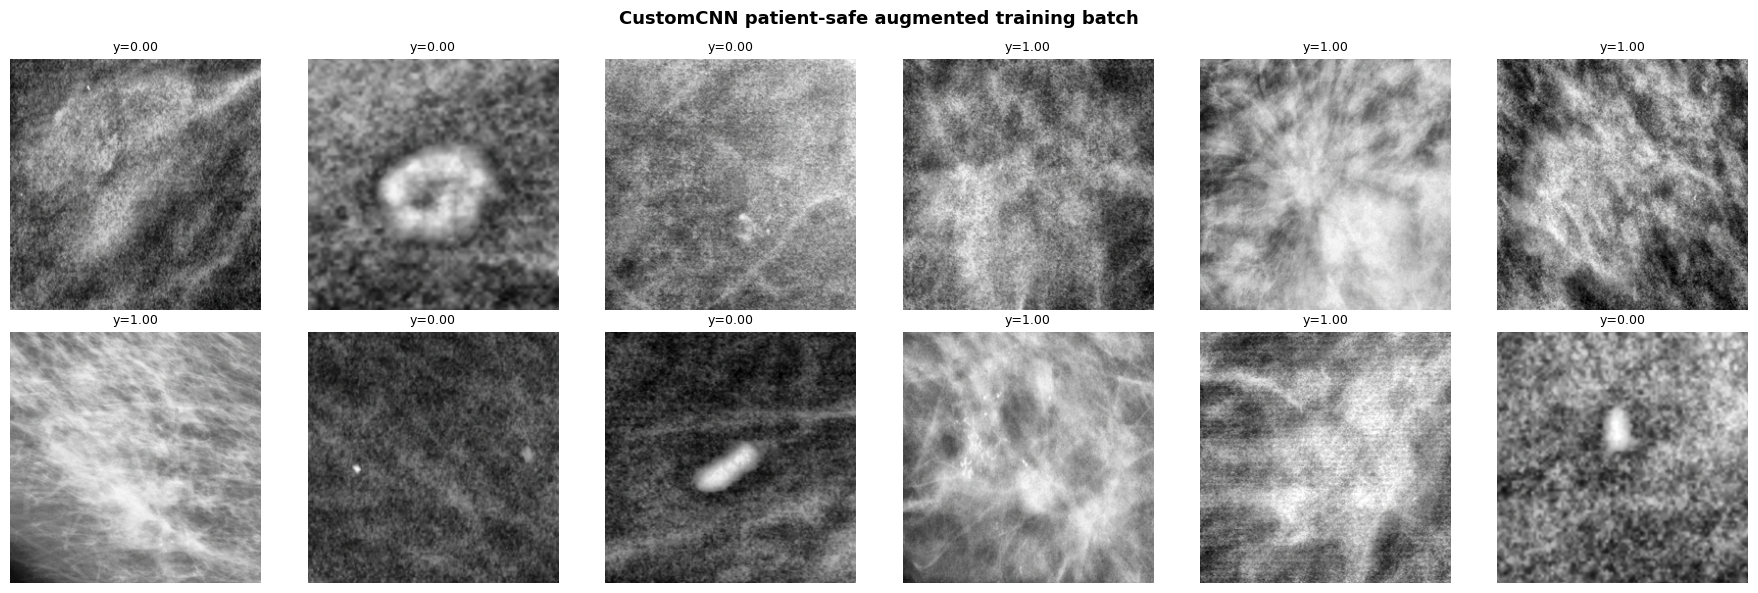

In [5]:
# ======================================================================================
# CELL 5 — Augmentation sanity check
# ======================================================================================
def deprocess_customcnn(x):
    """Convert CustomCNN-normalized [-1,1] tensor back to displayable RGB uint8."""
    if hasattr(x, "numpy"):
        x = x.numpy()
    return deprocess_input(x)

batch_x, batch_y = next(iter(train_ds_mix if USE_BATCH_MIXING else train_ds_clean))
print("Batch shape :", batch_x.shape)
print("Image range :", float(tf.reduce_min(batch_x)), "to", float(tf.reduce_max(batch_x)))
print("Label range :", float(tf.reduce_min(batch_y)), "to", float(tf.reduce_max(batch_y)))

assert batch_x.shape[1:] == (IMG_SIZE, IMG_SIZE, CHANNELS), "Image shape mismatch."
assert -1.2 <= float(tf.reduce_min(batch_x)) <= 0.0 and 0.0 <= float(tf.reduce_max(batch_x)) <= 1.2, "CustomCNN preprocess range looks wrong."

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, ax in enumerate(axes.flat):
    if i < batch_x.shape[0]:
        ax.imshow(deprocess_customcnn(batch_x[i]))
        ax.set_title(f"y={float(batch_y[i]):.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("CustomCNN patient-safe augmented training batch", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "augmentation_sanity.png", dpi=140, bbox_inches="tight")
plt.show()


In [6]:
# ======================================================================================
# CELL 6 — Build CustomCNN: ConvNeXt-style custom CNN + SE attention
# ======================================================================================
@tf.keras.utils.register_keras_serializable(package="CustomCNN")
class LayerScale(layers.Layer):
    def __init__(self, init_value=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.init_value = float(init_value)

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.gamma = self.add_weight(
            name="gamma",
            shape=(channels,),
            initializer=tf.keras.initializers.Constant(self.init_value),
            trainable=True,
        )

    def call(self, x):
        return x * self.gamma

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"init_value": self.init_value})
        return cfg

@tf.keras.utils.register_keras_serializable(package="CustomCNN")
class StochasticDepth(layers.Layer):
    def __init__(self, drop_rate=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_rate = float(drop_rate)

    def call(self, x, training=None):
        if (not training) or self.drop_rate <= 0.0:
            return x
        keep_prob = 1.0 - self.drop_rate
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        binary_tensor = tf.floor(random_tensor)
        return (x / keep_prob) * binary_tensor

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"drop_rate": self.drop_rate})
        return cfg

def se_block_2d(x, ratio=8, name="se"):
    channels = int(x.shape[-1])
    s = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)
    s = layers.Dense(max(channels // ratio, 16), activation="swish",
                     kernel_initializer="he_normal", name=f"{name}_fc1")(s)
    s = layers.Dense(channels, activation="sigmoid",
                     kernel_initializer="glorot_uniform", name=f"{name}_fc2")(s)
    s = layers.Reshape((1, 1, channels), name=f"{name}_reshape")(s)
    return layers.Multiply(name=f"{name}_scale")([x, s])

def conv_bn_gelu(x, filters, kernel=3, stride=1, name="conv"):
    x = layers.Conv2D(
        filters, kernel, strides=stride, padding="same", use_bias=False,
        kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG),
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("gelu", name=f"{name}_gelu")(x)
    return x

def convnext_se_block(x, drop_path=0.0, expansion=4, name="cnx"):
    """
    Custom ConvNeXt-style residual block:
    depthwise 7x7 -> LayerNorm -> pointwise MLP -> SE -> LayerScale -> stochastic depth.
    """
    channels = int(x.shape[-1])
    shortcut = x

    y = layers.DepthwiseConv2D(
        kernel_size=7, padding="same", use_bias=True,
        depthwise_initializer="he_normal",
        depthwise_regularizer=regularizers.l2(L2_REG),
        name=f"{name}_dw7",
    )(x)
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln")(y)

    y = layers.Conv2D(
        channels * expansion, 1, padding="same", use_bias=True,
        kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG),
        name=f"{name}_pw_expand",
    )(y)
    y = layers.Activation("gelu", name=f"{name}_gelu")(y)

    y = layers.Conv2D(
        channels, 1, padding="same", use_bias=True,
        kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG),
        name=f"{name}_pw_project",
    )(y)

    y = se_block_2d(y, ratio=8, name=f"{name}_se")
    y = LayerScale(1e-5, name=f"{name}_layerscale")(y)
    y = StochasticDepth(drop_path, name=f"{name}_droppath")(y)

    return layers.Add(name=f"{name}_add")([shortcut, y])

def downsample_block(x, filters, name="down"):
    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln")(x)
    x = layers.Conv2D(
        filters, 2, strides=2, padding="same", use_bias=False,
        kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG),
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return x

def build_customcnn_v8():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS), name="input")

    # Stronger stem than V6: low-level edges + coarse context.
    x = conv_bn_gelu(inputs, 32, kernel=5, stride=2, name="stem1")
    x = conv_bn_gelu(x, 48, kernel=3, stride=1, name="stem2")
    x = conv_bn_gelu(x, 64, kernel=3, stride=1, name="stem3")

    depths   = [2, 2, 4, 4, 2]
    channels = [64, 96, 160, 256, 384]
    total_blocks = sum(depths)
    block_id = 0
    max_drop_path = 0.12

    # Stage 1
    for j in range(depths[0]):
        dp = max_drop_path * block_id / max(total_blocks - 1, 1)
        x = convnext_se_block(x, drop_path=dp, expansion=3, name=f"stage1_block{j+1}")
        block_id += 1

    # Stages 2-5
    for si in range(1, len(depths)):
        x = downsample_block(x, channels[si], name=f"stage{si+1}_down")
        for j in range(depths[si]):
            dp = max_drop_path * block_id / max(total_blocks - 1, 1)
            x = convnext_se_block(x, drop_path=dp, expansion=4, name=f"stage{si+1}_block{j+1}")
            block_id += 1

    # Final semantic feature layer for Grad-CAM.
    feat = layers.Conv2D(
        448, 1, padding="same", use_bias=False,
        kernel_initializer="he_normal", kernel_regularizer=regularizers.l2(L2_REG),
        name="final_conv",
    )(x)
    feat = layers.BatchNormalization(name="final_bn")(feat)
    feat = layers.Activation("gelu", name="final_conv_out")(feat)

    backbone = Model(inputs, feat, name="custom_backbone")

    feat = backbone(inputs)
    feat = layers.SpatialDropout2D(0.10, name="spatial_drop")(feat)

    # Keep this exact GAP/GMP head pattern so MC-Dropout XAI remains architecture-aware.
    gap = layers.GlobalAveragePooling2D(name="gap")(feat)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(feat)
    x = layers.Concatenate(name="pool_concat")([gap, gmp])

    x = layers.BatchNormalization(name="head_bn0")(x)
    x = layers.Dropout(DROPOUT_RATE, name="head_drop0")(x)

    x = layers.Dense(
        512, use_bias=False, kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(L2_REG), name="head_fc1",
    )(x)
    x = layers.BatchNormalization(name="head_bn1")(x)
    x = layers.Activation("gelu", name="head_swish1")(x)
    x = layers.Dropout(0.32, name="head_drop1")(x)

    x = layers.Dense(
        192, use_bias=False, kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(L2_REG), name="head_fc2",
    )(x)
    x = layers.BatchNormalization(name="head_bn2")(x)
    x = layers.Activation("gelu", name="head_swish2")(x)
    x = layers.Dropout(0.22, name="head_drop2")(x)

    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(x)
    model = Model(inputs, outputs, name=MODEL_NAME)
    return model, backbone

model, base = build_customcnn_v8()
HEAD_LAYER_PREFIXES = ("spatial_drop", "gap", "gmp", "pool_concat", "head_", "output")

print(f"Total params     : {model.count_params():,}")
print(f"Trainable params : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
print("Backbone output  :", base.output_shape)
model.summary()


Total params     : 7,239,697
Trainable params : 7,233,521
Backbone output  : (None, 8, 8, 448)


Model: "CustomCNN_ULTRA_V8_PATIENT_SAFE_MAX"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_backbone     │ (None, 8, 8, 448) │  6,676,048 │ input[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_drop        │ (None, 8, 8, 448) │          0 │ custom_backbone[… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 448)       │          0 │ spatial_drop[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 448)       │          0 │ spatial_drop[0][… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_concat         │ (None, 896)       │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn0            │ (None, 896)       │      3,584 │ pool_concat[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop0          │ (None, 896)       │          0 │ head_bn0[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_fc1 (Dense)    │ (None, 512)       │    458,752 │ head_drop0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn1            │ (None, 512)       │      2,048 │ head_fc1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_swish1         │ (None, 512)       │          0 │ head_bn1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop1          │ (None, 512)       │          0 │ head_swish1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_fc2 (Dense)    │ (None, 192)       │     98,304 │ head_drop1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn2            │ (None, 192)       │        768 │ head_fc2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_swish2         │ (None, 192)       │          0 │ head_bn2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop2          │ (None, 192)       │          0 │ head_swish2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        193 │ head_drop2[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,239,697 (27.62 MB)

 Trainable params: 7,233,521 (27.59 MB)

 Non-trainable params: 6,176 (24.12 KB)

In [7]:
# ======================================================================================
# CELL 7 — Loss, LR schedule, callbacks, checkpoint utilities
# ======================================================================================
def weighted_bce_loss(label_smoothing=LABEL_SMOOTH):
    """Weighted BCE using CLASS_WEIGHTS."""
    w0 = tf.constant(CLASS_WEIGHTS[0], tf.float32)
    w1 = tf.constant(CLASS_WEIGHTS[1], tf.float32)
    ls = tf.constant(label_smoothing, tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        if label_smoothing > 0:
            y_true = y_true * (1.0 - ls) + 0.5 * ls

        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        weights = y_true * w1 + (1.0 - y_true) * w0
        return tf.reduce_mean(weights * bce)

    return loss_fn

def focal_bce_loss(gamma=FOCAL_GAMMA, alpha=None, label_smoothing=LABEL_SMOOTH):
    """
    Mild class-balanced focal BCE.
    Uses alpha for class balance and CLASS_WEIGHTS lightly for split imbalance.
    """
    if alpha is None:
        alpha = FOCAL_ALPHA

    alpha = tf.constant(float(alpha), tf.float32)
    gamma = tf.constant(float(gamma), tf.float32)
    ls = tf.constant(float(label_smoothing), tf.float32)
    w0 = tf.constant(CLASS_WEIGHTS[0], tf.float32)
    w1 = tf.constant(CLASS_WEIGHTS[1], tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        if label_smoothing > 0:
            y_true = y_true * (1.0 - ls) + 0.5 * ls

        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        pt = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)
        weight_t = y_true * w1 + (1.0 - y_true) * w0

        return tf.reduce_mean(weight_t * alpha_t * tf.pow(1.0 - pt, gamma) * bce)

    return loss_fn

def get_loss():
    return focal_bce_loss() if USE_FOCAL_LOSS else weighted_bce_loss()

class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps, min_lr=MIN_LR):
        super().__init__()
        self.peak_lr = float(peak_lr)
        self.total_steps = int(total_steps)
        self.warmup_steps = int(max(warmup_steps, 1))
        self.min_lr = float(min_lr)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.peak_lr * step / float(self.warmup_steps)
        progress = tf.clip_by_value(
            (step - self.warmup_steps) / max(float(self.total_steps - self.warmup_steps), 1.0),
            0.0,
            1.0,
        )
        cosine = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * (1.0 + tf.cos(math.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {
            "peak_lr": self.peak_lr,
            "total_steps": self.total_steps,
            "warmup_steps": self.warmup_steps,
            "min_lr": self.min_lr,
        }

def make_lr(lr, epochs):
    total_steps = max(epochs * steps_per_epoch, 1)
    warmup_steps = max(int(total_steps * WARMUP_FRAC), 1)
    return WarmupCosine(lr, total_steps, warmup_steps, MIN_LR)

def make_optimizer(lr_schedule):
    """
    AdamW + EMA when available.
    EMA often improves from-scratch CustomCNN generalization.
    """
    try:
        return optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=WEIGHT_DECAY,
            clipnorm=CLIPNORM,
            use_ema=True,
            ema_momentum=0.999,
        )
    except TypeError:
        try:
            return optimizers.AdamW(
                learning_rate=lr_schedule,
                weight_decay=WEIGHT_DECAY,
                clipnorm=CLIPNORM,
            )
        except Exception:
            print("AdamW unavailable; using Adam fallback.")
            return optimizers.Adam(learning_rate=lr_schedule, clipnorm=CLIPNORM)

METRICS = [
    tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
    tf.keras.metrics.AUC(name="auc", curve="ROC", num_thresholds=300),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR", num_thresholds=300),
    tf.keras.metrics.Precision(name="precision", thresholds=0.5),
    tf.keras.metrics.Recall(name="recall", thresholds=0.5),
]

class TopKSnapshotter(callbacks.Callback):
    def __init__(self, folder, prefix, k=TOP_K_SNAPSHOTS, monitor="val_auc"):
        super().__init__()
        self.folder = Path(folder)
        self.folder.mkdir(parents=True, exist_ok=True)
        self.prefix = prefix
        self.k = int(k)
        self.monitor = monitor
        self.records = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        score = logs.get(self.monitor)
        if score is None or not np.isfinite(score):
            return

        path = self.folder / f"{self.prefix}_epoch{epoch+1:03d}_{self.monitor}{float(score):.5f}.weights.h5"
        self.model.save_weights(str(path))
        self.records.append((float(score), str(path)))
        self.records = sorted(self.records, key=lambda x: x[0], reverse=True)

        for _, old in self.records[self.k:]:
            try:
                os.remove(old)
            except OSError:
                pass

        self.records = self.records[:self.k]

    def get_paths(self):
        return [p for _, p in sorted(self.records, key=lambda x: x[0], reverse=True) if os.path.exists(p)]

def set_customcnn_trainability(base_model=None, mode="all"):
    """CustomCNN is trained from scratch, so all convolutional stages stay trainable."""
    if base_model is not None:
        base_model.trainable = True
        for layer in base_model.layers:
            layer.trainable = True

    for layer in model.layers:
        layer.trainable = True

    n_train = sum(tf.size(w).numpy() for w in model.trainable_weights)
    print(f"Trainable params now: {n_train:,}")

    if base_model is not None:
        print("Last trainable backbone layers:", [l.name for l in base_model.layers if l.trainable][-12:])

def compile_model(lr, epochs):
    model.compile(
        optimizer=make_optimizer(make_lr(lr, epochs)),
        loss=get_loss(),
        metrics=METRICS,
    )

def predict_probs(weight_path, ds):
    model.load_weights(weight_path)
    return model.predict(ds, verbose=0).reshape(-1)

def select_best_candidate(candidates, val_ds, y_val, tag):
    rows = []

    for name, path in candidates:
        if path and os.path.exists(path):
            p = predict_probs(path, val_ds)
            auc = roc_auc_score(y_val, p)
            rows.append({"name": name, "path": path, "val_auc": float(auc)})
            print(f"{tag:<8} {name:<22} val_auc={auc:.5f}")

    assert rows, f"No valid candidates for {tag}"

    df = pd.DataFrame(rows).sort_values("val_auc", ascending=False).reset_index(drop=True)
    df.to_csv(SAVE_DIR / f"{tag}_candidate_val_auc.csv", index=False)

    return df.iloc[0].to_dict(), df


In [8]:
# ======================================================================================
# CELL 8 — Phase 1: CustomCNN representation learning
# ======================================================================================
print("\n" + "=" * 80)
print("PHASE 1 — CustomCNN V8 representation learning")
print("=" * 80)

set_customcnn_trainability(base, mode="all")

phase1_ckpt = str(SAVE_DIR / "phase1_best.weights.h5")
snap_p1 = TopKSnapshotter(SAVE_DIR / "snapshots_phase1", prefix="p1")
compile_model(PHASE1_LR, PHASE1_EPOCHS)

history_p1 = model.fit(
    train_ds_mix if USE_BATCH_MIXING else train_ds_clean,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        callbacks.ModelCheckpoint(phase1_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=12, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / "phase1_history.csv")),
        callbacks.TerminateOnNaN(),
        snap_p1,
    ],
    verbose=1,
)

print(f"Phase 1 best val_AUC = {max(history_p1.history.get('val_auc', [0])):.5f}")



PHASE 1 — CustomCNN V8 representation learning
Trainable params now: 7,233,521
Last trainable backbone layers: ['stage5_block2_pw_project', 'stage5_block2_se_gap', 'stage5_block2_se_fc1', 'stage5_block2_se_fc2', 'stage5_block2_se_reshape', 'stage5_block2_se_scale', 'stage5_block2_layerscale', 'stage5_block2_droppath', 'stage5_block2_add', 'final_conv', 'final_bn', 'final_conv_out']
Epoch 1/70
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 888ms/step - accuracy: 0.4706 - auc: 0.4992 - loss: 0.5319 - pr_auc: 0.4159 - precision: 0.3967 - recall: 0.5454
Epoch 1: val_auc improved from None to 0.56290, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/phase1_best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.4938 - auc: 0.5198 - loss: 0.5237 - pr_auc: 0.4247 - precision: 0.4142 - recall: 0.56

In [9]:
# ======================================================================================
# CELL 9 — Phase 2: lower-LR full CustomCNN refinement
# ======================================================================================
print("\n" + "=" * 80)
print("PHASE 2 — Lower-LR CustomCNN V8 refinement")
print("=" * 80)

model.load_weights(phase1_ckpt)
set_customcnn_trainability(base, mode="all")

phase2_ckpt = str(SAVE_DIR / "phase2_best.weights.h5")
snap_p2 = TopKSnapshotter(SAVE_DIR / "snapshots_phase2", prefix="p2")
compile_model(PHASE2_LR, PHASE2_EPOCHS)

history_p2 = model.fit(
    train_ds_clean,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        callbacks.ModelCheckpoint(phase2_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=14, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / "phase2_history.csv")),
        callbacks.TerminateOnNaN(),
        snap_p2,
    ],
    verbose=1,
)

print(f"Phase 2 best val_AUC = {max(history_p2.history.get('val_auc', [0])):.5f}")

# Select the best after Phase 2 immediately.
y_val = val_df["label"].astype(int).values
phase2_candidates = [("phase1_best", phase1_ckpt), ("phase2_best", phase2_ckpt)]
phase2_candidates += [(f"p1_snapshot_{i+1}", p) for i, p in enumerate(snap_p1.get_paths())]
phase2_candidates += [(f"p2_snapshot_{i+1}", p) for i, p in enumerate(snap_p2.get_paths())]
best_p2, p2_df = select_best_candidate(phase2_candidates, val_ds, y_val, tag="p2_select")
selected_p2_path = best_p2["path"]
print("Selected for Phase 3:", best_p2)



PHASE 2 — Lower-LR CustomCNN V8 refinement
Trainable params now: 7,233,521
Last trainable backbone layers: ['stage5_block2_pw_project', 'stage5_block2_se_gap', 'stage5_block2_se_fc1', 'stage5_block2_se_fc2', 'stage5_block2_se_reshape', 'stage5_block2_se_scale', 'stage5_block2_layerscale', 'stage5_block2_droppath', 'stage5_block2_add', 'final_conv', 'final_bn', 'final_conv_out']
Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.5814 - auc: 0.6629 - loss: 0.1817 - pr_auc: 0.5509 - precision: 0.4929 - recall: 0.7884
Epoch 1: val_auc improved from None to 0.68476, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/phase2_best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 216s 879ms/step - accuracy: 0.5818 - auc: 0.6604 - loss: 0.1799 - pr_auc: 0.5439 - precision: 0.4915 - recall: 0.775

In [10]:
# ======================================================================================
# CELL 10 — Phase 3: tiny-LR full CustomCNN polish
# ======================================================================================
print("\n" + "=" * 80)
print("PHASE 3 — Tiny-LR CustomCNN V8 polish")
print("=" * 80)

model.load_weights(selected_p2_path)
set_customcnn_trainability(base, mode="all")

phase3_ckpt = str(SAVE_DIR / "phase3_best.weights.h5")
snap_p3 = TopKSnapshotter(SAVE_DIR / "snapshots_phase3", prefix="p3")
compile_model(PHASE3_LR, PHASE3_EPOCHS)

history_p3 = model.fit(
    train_ds_clean,
    epochs=PHASE3_EPOCHS,
    validation_data=val_ds,
    callbacks=[
        callbacks.ModelCheckpoint(phase3_ckpt, monitor="val_auc", mode="max", save_best_only=True, save_weights_only=True, verbose=1),
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=12, restore_best_weights=True, verbose=1),
        callbacks.CSVLogger(str(SAVE_DIR / "phase3_history.csv")),
        callbacks.TerminateOnNaN(),
        snap_p3,
    ],
    verbose=1,
)

print(f"Phase 3 best val_AUC = {max(history_p3.history.get('val_auc', [0])):.5f}")

candidate_pool = [
    ("phase1_best", phase1_ckpt),
    ("phase2_best", phase2_ckpt),
    ("phase2_selected", selected_p2_path),
    ("phase3_best", phase3_ckpt),
]
candidate_pool += [(f"p1_snapshot_{i+1}", p) for i, p in enumerate(snap_p1.get_paths())]
candidate_pool += [(f"p2_snapshot_{i+1}", p) for i, p in enumerate(snap_p2.get_paths())]
candidate_pool += [(f"p3_snapshot_{i+1}", p) for i, p in enumerate(snap_p3.get_paths())]

best_final, candidate_df = select_best_candidate(candidate_pool, val_ds, y_val, tag="final")
final_single_path = str(SAVE_DIR / "final_single_best.weights.h5")
model.load_weights(best_final["path"])
model.save_weights(final_single_path)
model.save(str(SAVE_DIR / "customcnn_ultra_v8_final_single.keras"))
print("Final selected single checkpoint:", best_final)



PHASE 3 — Tiny-LR CustomCNN V8 polish
Trainable params now: 7,233,521
Last trainable backbone layers: ['stage5_block2_pw_project', 'stage5_block2_se_gap', 'stage5_block2_se_fc1', 'stage5_block2_se_fc2', 'stage5_block2_se_reshape', 'stage5_block2_se_scale', 'stage5_block2_layerscale', 'stage5_block2_droppath', 'stage5_block2_add', 'final_conv', 'final_bn', 'final_conv_out']
Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.5970 - auc: 0.7124 - loss: 0.1651 - pr_auc: 0.6004 - precision: 0.4941 - recall: 0.8661
Epoch 1: val_auc improved from None to 0.69714, saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/phase3_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/phase3_best.weights.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 222s 914ms/step - accuracy: 0.6056 - auc: 0.7078 - loss: 0.1678 - pr_auc: 0.6072 - precision: 0.5095 - recall: 0.8528 - v

In [11]:
# ======================================================================================
# CELL 11 — Candidate probability ensemble + deterministic TTA
# ======================================================================================
print("\n" + "=" * 80)
print("FINAL CANDIDATE SELECTION + TTA")
print("=" * 80)

y_val = val_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

# Clean validation candidate ranking.
clean_rows = []
val_probs_by_name = {}
for name, path in candidate_pool + [("final_single", final_single_path)]:
    if path is None or not os.path.exists(path):
        continue
    p = predict_probs(path, val_ds)
    auc = roc_auc_score(y_val, p)
    clean_rows.append({"name": name, "path": path, "clean_val_auc": float(auc)})
    val_probs_by_name[name] = p
    print(f"{name:<22} clean val_auc={auc:.5f}")

clean_df = pd.DataFrame(clean_rows).drop_duplicates(subset=["path"]).sort_values("clean_val_auc", ascending=False).reset_index(drop=True)
clean_df.to_csv(SAVE_DIR / "all_candidate_clean_val_auc.csv", index=False)

best_single_name = clean_df.loc[0, "name"]
best_single_path = clean_df.loc[0, "path"]
best_single_auc  = float(clean_df.loc[0, "clean_val_auc"])

# Top-N probability ensemble. Use only if validation AUC improves.
topn = clean_df.head(min(3, len(clean_df)))
topn_names = topn["name"].tolist()
topn_paths = topn["path"].tolist()
ens_val_clean = np.mean([val_probs_by_name[n] for n in topn_names], axis=0)
ens_clean_auc = roc_auc_score(y_val, ens_val_clean)

print("\nClean validation comparison")
print(f"Best single : {best_single_name} AUC={best_single_auc:.5f}")
print(f"Top ensemble: {topn_names} AUC={ens_clean_auc:.5f}")

USE_ENSEMBLE = ens_clean_auc >= best_single_auc + 0.001
if USE_ENSEMBLE:
    final_weight_paths = topn_paths
    print("→ Using validation-improving top checkpoint probability ensemble.")
else:
    final_weight_paths = [best_single_path]
    print("→ Using best single checkpoint; ensemble did not improve validation AUC enough.")

def tta_predict_weight_files(weight_paths, static_ds, n_tta=TTA_STEPS, name="set"):
    per_model_probs = []
    n_tta = min(int(n_tta), 8)
    for wi, wpath in enumerate(weight_paths, start=1):
        print(f"\nWeights {wi}/{len(weight_paths)}: {Path(wpath).name}")
        model.load_weights(wpath)
        view_probs = []
        for t in range(n_tta):
            ds_tta = make_tta_ds(static_ds, t)
            p = model.predict(ds_tta, verbose=0).reshape(-1)
            view_probs.append(p)
            print(f"  {name} TTA {t+1}/{n_tta}: mean={p.mean():.5f}")
        per_model_probs.append(np.mean(view_probs, axis=0))
    return np.mean(per_model_probs, axis=0)

print("\nPredicting validation with final TTA setup...")
val_prob = tta_predict_weight_files(final_weight_paths, val_static, n_tta=TTA_STEPS, name="val")

print("\nPredicting test with final TTA setup...")
test_prob = tta_predict_weight_files(final_weight_paths, test_static, n_tta=TTA_STEPS, name="test")

print(f"\nVal TTA AUC : {roc_auc_score(y_val, val_prob):.5f}")
print(f"Test prob range: [{test_prob.min():.5f}, {test_prob.max():.5f}], mean={test_prob.mean():.5f}")



FINAL CANDIDATE SELECTION + TTA
phase1_best            clean val_auc=0.67821
phase2_best            clean val_auc=0.70078
phase2_selected        clean val_auc=0.70078
phase3_best            clean val_auc=0.70545
p1_snapshot_1          clean val_auc=0.67821
p1_snapshot_2          clean val_auc=0.67263
p1_snapshot_3          clean val_auc=0.67160
p1_snapshot_4          clean val_auc=0.67014
p1_snapshot_5          clean val_auc=0.67038
p2_snapshot_1          clean val_auc=0.70078
p2_snapshot_2          clean val_auc=0.69917
p2_snapshot_3          clean val_auc=0.69644
p2_snapshot_4          clean val_auc=0.69712
p2_snapshot_5          clean val_auc=0.69546
p3_snapshot_1          clean val_auc=0.70545
p3_snapshot_2          clean val_auc=0.70442
p3_snapshot_3          clean val_auc=0.70232
p3_snapshot_4          clean val_auc=0.70151
p3_snapshot_5          clean val_auc=0.70202
final_single           clean val_auc=0.70545

Clean validation comparison
Best single : phase3_best AUC=0.70545


In [12]:
# ======================================================================================
# CELL 12 — Validation-only threshold tuning + final test evaluation
# ======================================================================================
def metric_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    npv = tn / max(tn + fn, 1)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0.0

    return {
        "thr": float(thr),
        "acc": float(acc),
        "bal_acc": float(bal),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(prec),
        "recall": float(rec),
        "npv": float(npv),
        "f1": float(f1),
        "mcc": float(mcc),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }

def build_threshold_table(y_true, y_prob):
    grid = np.linspace(0.05, 0.95, 181)
    rows = [metric_at_threshold(y_true, y_prob, t) for t in grid]
    df = pd.DataFrame(rows)

    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    finite = np.isfinite(thr_roc)

    youden_thr = float(thr_roc[finite][np.argmax((tpr - fpr)[finite])]) if finite.any() else 0.5
    best_bal = float(df.loc[df["bal_acc"].idxmax(), "thr"])
    best_f1  = float(df.loc[df["f1"].idxmax(), "thr"])
    best_mcc = float(df.loc[df["mcc"].idxmax(), "thr"])

    # Medical objective: prefer sensitivity, but avoid destroying balanced accuracy.
    df["medical_score"] = (
        0.40 * df["bal_acc"] +
        0.35 * df["f1"] +
        0.20 * df["sensitivity"] +
        0.05 * df["npv"]
    )

    sens_candidates = df[df["sensitivity"] >= TARGET_MIN_SENSITIVITY].copy()
    if len(sens_candidates) > 0:
        best_medical = float(sens_candidates.loc[sens_candidates["medical_score"].idxmax(), "thr"])
    else:
        best_medical = float(df.loc[df["medical_score"].idxmax(), "thr"])

    robust_thr = float(np.median([best_bal, best_mcc, youden_thr, best_medical]))
    robust_thr = float(np.clip(robust_thr, 0.05, 0.95))

    return df, {
        "thr_0.50": 0.50,
        "thr_bal_acc": best_bal,
        "thr_f1": best_f1,
        "thr_mcc": best_mcc,
        "thr_youden": youden_thr,
        "thr_medical": best_medical,
        "thr_robust": robust_thr,
    }

thr_df, thresholds = build_threshold_table(y_val, val_prob)
thr_df.to_csv(SAVE_DIR / "validation_threshold_search.csv", index=False)

print("\nValidation thresholds")
for k, v in thresholds.items():
    m = metric_at_threshold(y_val, val_prob, v)
    print(f"{k:<14}: {v:.5f} | val BalAcc={m['bal_acc']:.4f} F1={m['f1']:.4f} Sens={m['sensitivity']:.4f} Spec={m['specificity']:.4f}")

# Use medical validation threshold by default because the user cares about sensitivity.
# This is still leakage-safe because it is selected on validation only.
OPT_THR = thresholds["thr_medical"]
print(f"\n→ Selected validation medical threshold: {OPT_THR:.5f}")

auc_roc = roc_auc_score(y_test, test_prob)
pr_auc = average_precision_score(y_test, test_prob)
metrics_050 = metric_at_threshold(y_test, test_prob, 0.50)
metrics_opt = metric_at_threshold(y_test, test_prob, OPT_THR)
metrics_robust = metric_at_threshold(y_test, test_prob, thresholds["thr_robust"])

def print_metric_block(title, m):
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Acc={m['acc']:.4f} | BalAcc={m['bal_acc']:.4f} | F1={m['f1']:.4f} | MCC={m['mcc']:.4f}")
    print(f"Sens={m['sensitivity']:.4f} | Spec={m['specificity']:.4f} | Prec={m['precision']:.4f} | NPV={m['npv']:.4f}")
    print(f"TP={m['tp']} TN={m['tn']} FP={m['fp']} FN={m['fn']}")

print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)
print(f"ROC-AUC : {auc_roc:.5f}")
print(f"PR-AUC  : {pr_auc:.5f}")
print_metric_block("Threshold = 0.50", metrics_050)
print_metric_block(f"Threshold = {OPT_THR:.5f} (validation medical)", metrics_opt)
print_metric_block(f"Threshold = {thresholds['thr_robust']:.5f} (validation robust)", metrics_robust)

y_pred_opt = (test_prob >= OPT_THR).astype(int)

print("\nClassification report")
print(classification_report(y_test, y_pred_opt, target_names=["benign", "malignant"], digits=4, zero_division=0))

pred_df = pd.DataFrame({
    "path": test_df["path"].values,
    "true_label": y_test,
    "prob_malignant": test_prob,
    "pred_label": y_pred_opt,
})
pred_df.to_csv(SAVE_DIR / "test_predictions_tta.csv", index=False)

summary = {
    "model": MODEL_NAME,
    "img_size": IMG_SIZE,
    "resize_size": RESIZE_SIZE,
    "batch_size": BATCH_SIZE,
    "train_count": len(train_df),
    "val_count": len(val_df),
    "test_count": len(test_df),
    "loss": "focal_bce" if USE_FOCAL_LOSS else "weighted_bce",
    "tta_steps": TTA_STEPS,
    "used_ensemble": bool(USE_ENSEMBLE),
    "ensemble_members": "|".join([Path(p).name for p in final_weight_paths]),
    "opt_threshold": float(OPT_THR),
    "robust_threshold": float(thresholds["thr_robust"]),
    "auc_roc": float(auc_roc),
    "pr_auc": float(pr_auc),
    **{f"test_{k}": v for k, v in metrics_opt.items()},
}
pd.DataFrame([summary]).to_csv(SAVE_DIR / "results_summary.csv", index=False)

print(f"\nSaved results to: {SAVE_DIR}")

# Aliases used by dashboard and XAI cells.
y_true = y_test
y_prob = test_prob
auc_roc = float(auc_roc)
ap = float(pr_auc)
OPTIMAL_THRESHOLD = float(OPT_THR)



Validation thresholds
thr_0.50      : 0.50000 | val BalAcc=0.6231 F1=0.6175 Sens=0.8889 Spec=0.3574
thr_bal_acc   : 0.58000 | val BalAcc=0.6441 F1=0.5810 Sens=0.6162 Spec=0.6721
thr_f1        : 0.49000 | val BalAcc=0.6209 F1=0.6183 Sens=0.9040 Spec=0.3377
thr_mcc       : 0.60500 | val BalAcc=0.6430 F1=0.5547 Sens=0.5253 Spec=0.7607
thr_youden    : 0.60880 | val BalAcc=0.6453 F1=0.5553 Sens=0.5202 Spec=0.7705
thr_medical   : 0.41000 | val BalAcc=0.6021 F1=0.6166 Sens=0.9747 Spec=0.2295
thr_robust    : 0.59250 | val BalAcc=0.6344 F1=0.5578 Sens=0.5606 Spec=0.7082

→ Selected validation medical threshold: 0.41000

FINAL TEST RESULTS
ROC-AUC : 0.67665
PR-AUC  : 0.56749

Threshold = 0.50
----------------
Acc=0.5652 | BalAcc=0.6069 | F1=0.6205 | MCC=0.2372
Sens=0.8545 | Spec=0.3592 | Prec=0.4870 | NPV=0.7762
TP=188 TN=111 FP=198 FN=32

Threshold = 0.41000 (validation medical)
----------------------------------------
Acc=0.5066 | BalAcc=0.5718 | F1=0.6179 | MCC=0.2141
Sens=0.9591 | Spec=0.18

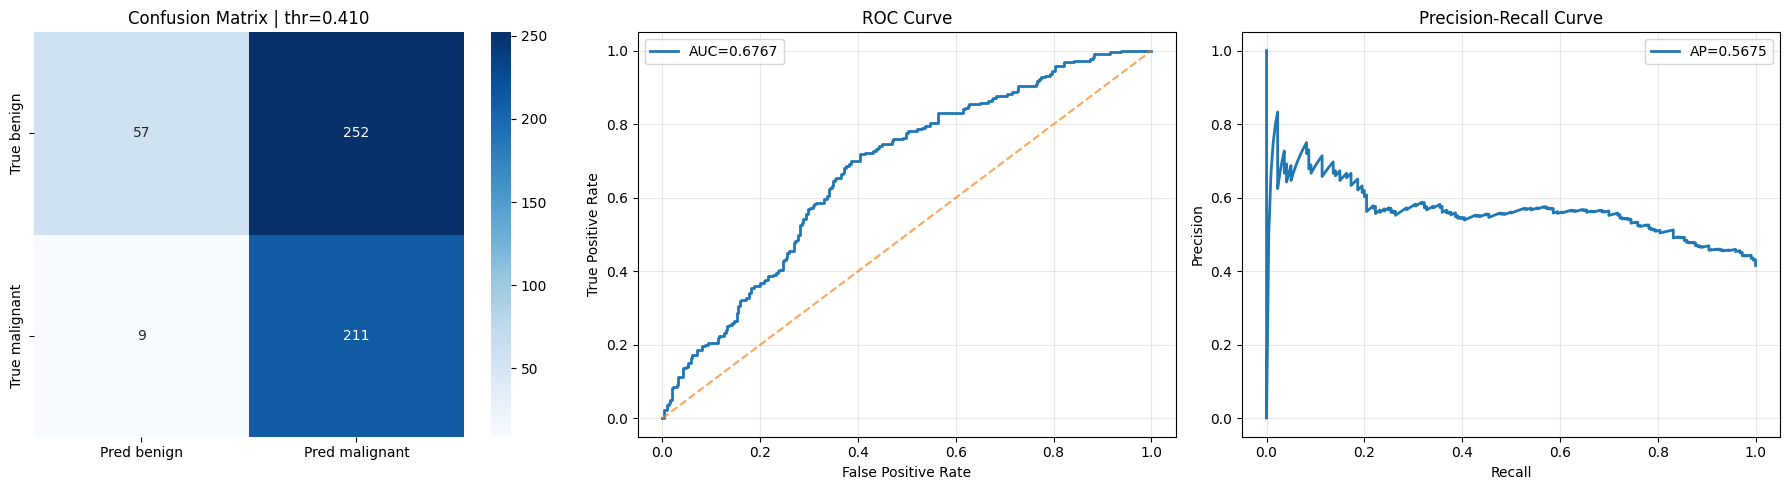

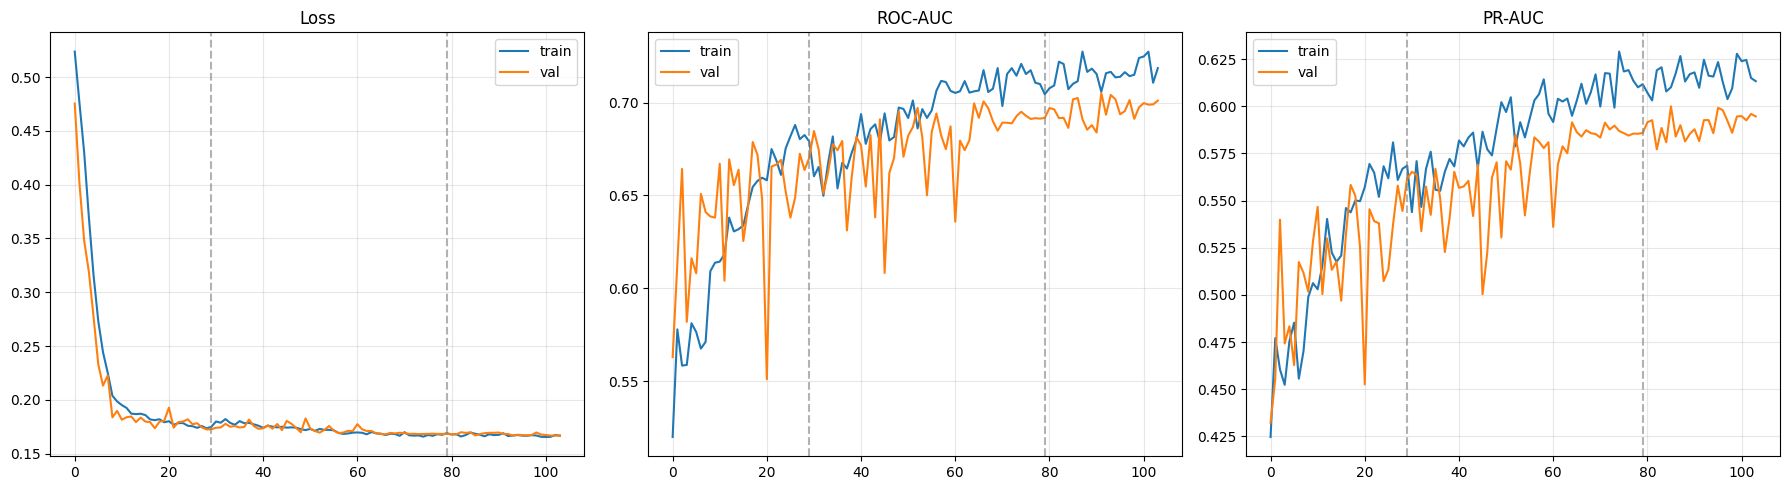

✅ CustomCNN_ULTRA_V8_PATIENT_SAFE_MAX complete.
ROC-AUC=0.67665 | PR-AUC=0.56749 | F1=0.61786
Sensitivity=0.95909 | Specificity=0.18447
Important check: patient leakage audit above must show zero patient overlap.


In [13]:
# ======================================================================================
# CELL 13 — Plots and final dashboard
# ======================================================================================
fpr, tpr, _ = roc_curve(y_test, test_prob)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_prob)
cm = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred benign", "Pred malignant"],
            yticklabels=["True benign", "True malignant"])
axes[0].set_title(f"Confusion Matrix | thr={OPT_THR:.3f}")

axes[1].plot(fpr, tpr, lw=2, label=f"AUC={auc_roc:.4f}")
axes[1].plot([0, 1], [0, 1], "--", alpha=0.7)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(rec_curve, prec_curve, lw=2, label=f"AP={pr_auc:.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / "final_eval_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Training curve plot.
def get_hist(h, key):
    return list(h.history.get(key, []))

all_hist = {
    "loss": get_hist(history_p1, "loss") + get_hist(history_p2, "loss") + get_hist(history_p3, "loss"),
    "val_loss": get_hist(history_p1, "val_loss") + get_hist(history_p2, "val_loss") + get_hist(history_p3, "val_loss"),
    "auc": get_hist(history_p1, "auc") + get_hist(history_p2, "auc") + get_hist(history_p3, "auc"),
    "val_auc": get_hist(history_p1, "val_auc") + get_hist(history_p2, "val_auc") + get_hist(history_p3, "val_auc"),
    "pr_auc": get_hist(history_p1, "pr_auc") + get_hist(history_p2, "pr_auc") + get_hist(history_p3, "pr_auc"),
    "val_pr_auc": get_hist(history_p1, "val_pr_auc") + get_hist(history_p2, "val_pr_auc") + get_hist(history_p3, "val_pr_auc"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tr, va, title in [
    (axes[0], "loss", "val_loss", "Loss"),
    (axes[1], "auc", "val_auc", "ROC-AUC"),
    (axes[2], "pr_auc", "val_pr_auc", "PR-AUC"),
]:
    ax.plot(all_hist[tr], label="train")
    ax.plot(all_hist[va], label="val")
    ax.axvline(len(get_hist(history_p1, "loss")) - 1, color="gray", ls="--", alpha=0.6)
    ax.axvline(len(get_hist(history_p1, "loss")) + len(get_hist(history_p2, "loss")) - 1, color="gray", ls="--", alpha=0.6)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ CustomCNN_ULTRA_V8_PATIENT_SAFE_MAX complete.")
print(f"ROC-AUC={auc_roc:.5f} | PR-AUC={pr_auc:.5f} | F1={metrics_opt['f1']:.5f}")
print(f"Sensitivity={metrics_opt['sensitivity']:.5f} | Specificity={metrics_opt['specificity']:.5f}")
print("Important check: patient leakage audit above must show zero patient overlap.")


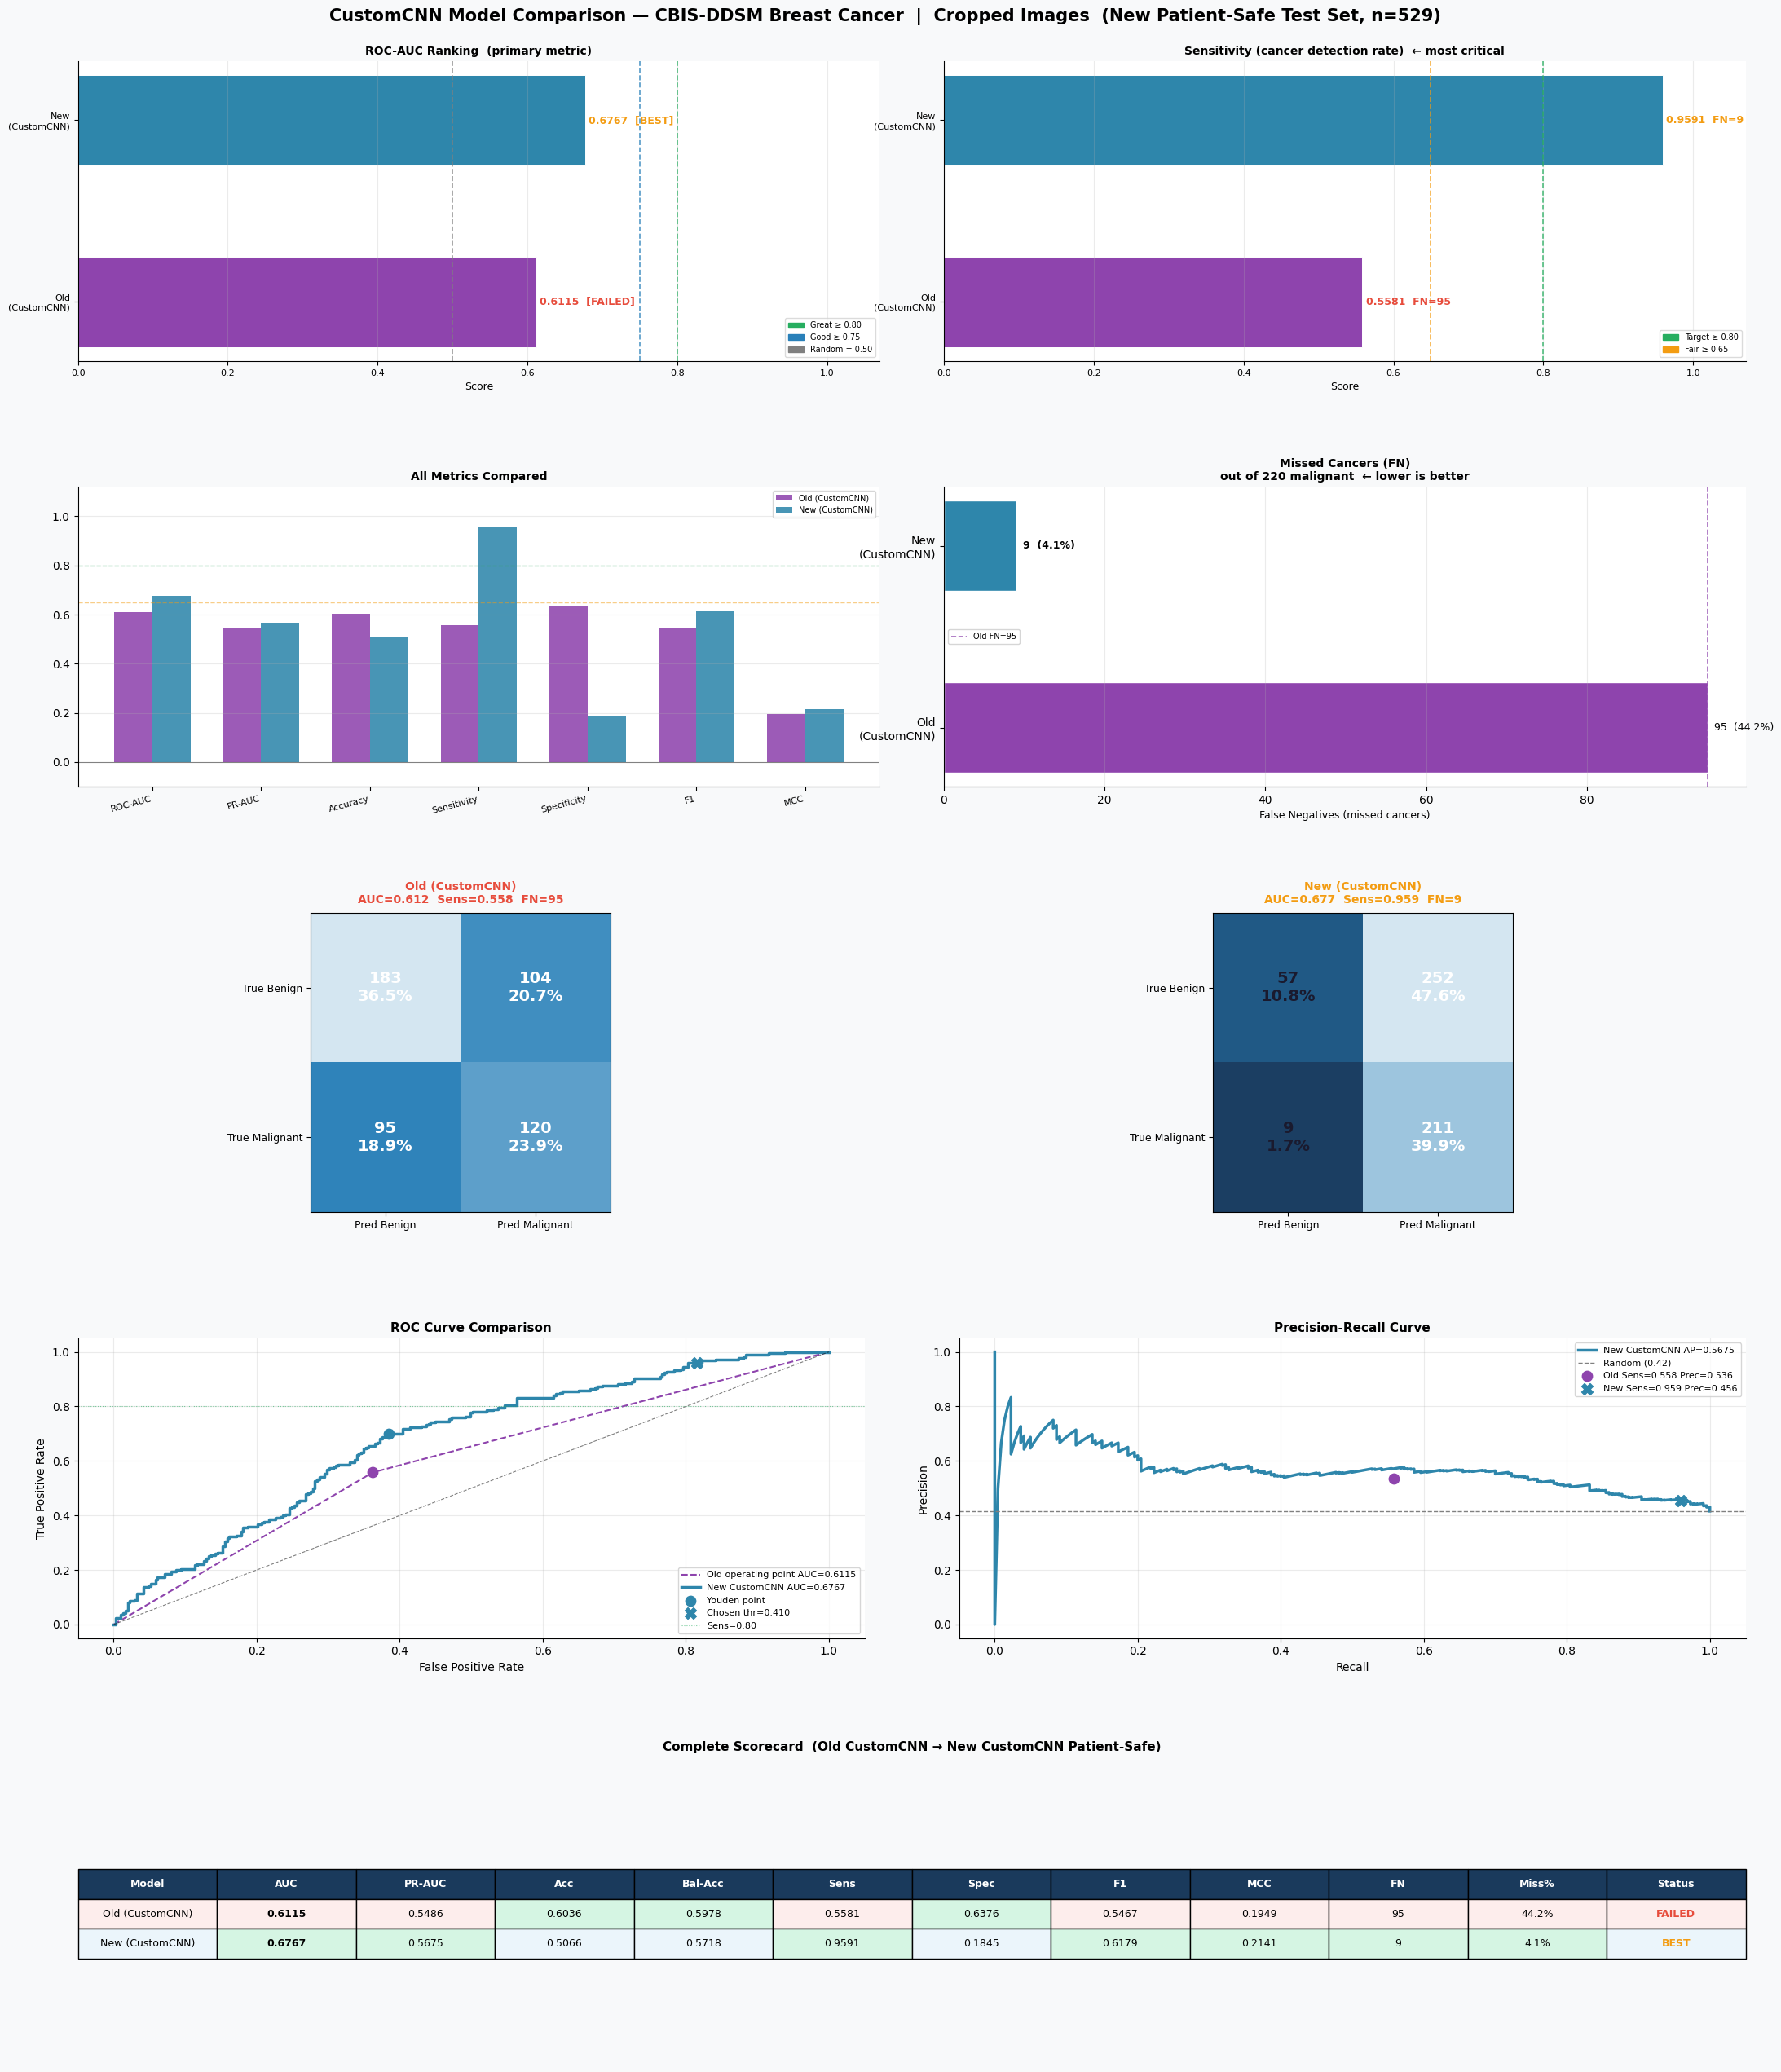

✅ CustomCNN comparison dashboard saved → /content/drive/MyDrive/THESIS/cbis-ddsm/model_output_v8/customcnn_patient_safe_v8_max/customcnn_old_vs_new_comparison_dashboard.png


In [14]:
# ============================================================================
# CELL 14 - CustomCNN Old vs New Comprehensive Comparison Dashboard
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
)

# ── Safety check ─────────────────────────────────────────────────────────────
_required = ["y_true", "y_prob", "SAVE_DIR"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        "Run the CustomCNN test evaluation cells first. "
        f"Missing variables: {_missing}"
    )

if "OPTIMAL_THRESHOLD" not in globals():
    if "OPT_THR" in globals():
        OPTIMAL_THRESHOLD = float(OPT_THR)
    else:
        print("⚠️ OPTIMAL_THRESHOLD not found. Using threshold=0.50.")
        OPTIMAL_THRESHOLD = 0.50

# ── Helpers ─────────────────────────────────────────────────────────────────
def status_color(auc):
    if auc >= 0.80:
        return "#27AE60"
    if auc >= 0.75:
        return "#2980B9"
    if auc >= 0.65:
        return "#F39C12"
    return "#E74C3C"

def status_label(auc):
    if auc >= 0.80:
        return "GREAT"
    if auc >= 0.75:
        return "GOOD"
    if auc >= 0.65:
        return "FAIR"
    return "FAILED"

def clean_ax(ax, axis="both"):
    ax.grid(axis=axis, alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

def safe_div(a, b):
    return 0.0 if b == 0 else a / b

# ── Current New CustomCNN metrics from live notebook arrays ───────────────────
y_true_dash = np.asarray(y_true).astype(int)
y_prob_dash = np.asarray(y_prob).astype(float)
y_pred_dash = (y_prob_dash >= float(OPTIMAL_THRESHOLD)).astype(int)

cm_new = confusion_matrix(y_true_dash, y_pred_dash, labels=[0, 1])
_tn, _fp, _fn, _tp = [int(x) for x in cm_new.ravel()]

_acc  = safe_div(_tp + _tn, _tp + _tn + _fp + _fn)
_sens = safe_div(_tp, _tp + _fn)
_spec = safe_div(_tn, _tn + _fp)
_prec = safe_div(_tp, _tp + _fp)
_f1   = f1_score(y_true_dash, y_pred_dash, zero_division=0)
_mcc  = matthews_corrcoef(y_true_dash, y_pred_dash) if len(set(y_pred_dash)) > 1 else 0.0
_bal  = balanced_accuracy_score(y_true_dash, y_pred_dash)
_auc  = roc_auc_score(y_true_dash, y_prob_dash)
_ap   = average_precision_score(y_true_dash, y_prob_dash)

# ── Model registry ───────────────────────────────────────────────────────────
# Old CustomCNN values from uploaded 6-model final comparison chart:
# AUC=.6115, PR-AUC=.5486, Acc=.6036, Sens=.5581, Spec=.6376,
# F1=.5467, MCC=.1949, TN=183, FP=104, FN=95, TP=120.
_b_tp, _b_tn, _b_fp, _b_fn = 120, 183, 104, 95

MODELS = {
    "Old\n(CustomCNN)": dict(
        color="#8E44AD",
        auc=0.6115,
        pr_auc=0.5486,
        acc=0.6036,
        sens=0.5581,
        spec=0.6376,
        prec=_b_tp / (_b_tp + _b_fp),
        f1=0.5467,
        mcc=0.1949,
        fn=_b_fn,
        tp=_b_tp,
        tn=_b_tn,
        fp=_b_fp,
        n_mal=_b_tp + _b_fn,
        thr=None,
    ),
    "New\n(CustomCNN)": dict(
        color="#2E86AB",
        auc=float(_auc),
        pr_auc=float(_ap),
        acc=float(_acc),
        sens=float(_sens),
        spec=float(_spec),
        prec=float(_prec),
        f1=float(_f1),
        mcc=float(_mcc),
        fn=int(_fn),
        tp=int(_tp),
        tn=int(_tn),
        fp=int(_fp),
        n_mal=int(_tp + _fn),
        thr=float(OPTIMAL_THRESHOLD),
    ),
}

names = list(MODELS.keys())
colors = [MODELS[n]["color"] for n in names]
best_auc_name = max(names, key=lambda n: MODELS[n]["auc"])

def display_status(nm):
    return "BEST" if nm == best_auc_name else status_label(MODELS[nm]["auc"])

n_test_total = _tp + _tn + _fp + _fn
n_malignant = _tp + _fn

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor="#F8F9FA")
fig.suptitle(
    f"CustomCNN Model Comparison — CBIS-DDSM Breast Cancer  |  Cropped Images"
    f"  (New Patient-Safe Test Set, n={n_test_total})",
    fontsize=15,
    fontweight="bold",
    y=0.99,
)

outer = gridspec.GridSpec(
    5, 1,
    figure=fig,
    hspace=0.42,
    top=0.965,
    bottom=0.02,
    left=0.05,
    right=0.98,
)

# ── ROW 0: AUC ranking | sensitivity ranking ────────────────────────────────
row0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.08)
ax_auc = fig.add_subplot(row0[0])
ax_sens = fig.add_subplot(row0[1])

rank_auc = sorted(names, key=lambda n: MODELS[n]["auc"], reverse=True)
rank_sens = sorted(names, key=lambda n: MODELS[n]["sens"], reverse=True)

for ax, metric, order, title, reflines in [
    (
        ax_auc,
        "auc",
        rank_auc,
        "ROC-AUC Ranking  (primary metric)",
        [
            (0.80, "#27AE60", "Great ≥ 0.80"),
            (0.75, "#2980B9", "Good ≥ 0.75"),
            (0.50, "gray", "Random = 0.50"),
        ],
    ),
    (
        ax_sens,
        "sens",
        rank_sens,
        "Sensitivity (cancer detection rate)  ← most critical",
        [
            (0.80, "#27AE60", "Target ≥ 0.80"),
            (0.65, "#F39C12", "Fair ≥ 0.65"),
        ],
    ),
]:
    vals = [MODELS[n][metric] for n in order]
    cols = [MODELS[n]["color"] for n in order]

    bars = ax.barh(order, vals, color=cols, height=0.5, edgecolor="white", linewidth=0.7)
    ax.invert_yaxis()

    for bar, val, nm in zip(bars, vals, order):
        sc = status_color(MODELS[nm]["auc"])
        label = (
            f"{val:.4f}  [{display_status(nm)}]"
            if metric == "auc"
            else f"{val:.4f}  FN={MODELS[nm]['fn']}"
        )
        ax.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=9,
            color=sc,
            fontweight="bold",
        )

    for xv, c, lbl in reflines:
        ax.axvline(xv, color=c, ls="--", lw=1.2, alpha=0.8)

    ax.set_xlim(0, 1.07)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Score", fontsize=9)
    clean_ax(ax, axis="x")

    handles = [mpatches.Patch(color=c, label=lbl) for _, c, lbl in reflines]
    ax.legend(handles=handles, fontsize=7, loc="lower right", framealpha=0.7)

# ── ROW 1: all metrics | missed cancers ─────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], wspace=0.08)
ax_multi = fig.add_subplot(row1[0])
ax_fn = fig.add_subplot(row1[1])

MK = ["auc", "pr_auc", "acc", "sens", "spec", "f1", "mcc"]
MLBL = ["ROC-AUC", "PR-AUC", "Accuracy", "Sensitivity", "Specificity", "F1", "MCC"]

x = np.arange(len(MK))
bw = 0.35

for i, nm in enumerate(names):
    vals = [MODELS[nm][k] for k in MK]
    ax_multi.bar(
        x + (i - 0.5) * bw,
        vals,
        bw,
        color=MODELS[nm]["color"],
        alpha=0.88,
        label=nm.replace("\n", " "),
    )

all_vals = [MODELS[nm][k] for nm in names for k in MK]
ax_multi.set_xticks(x)
ax_multi.set_xticklabels(MLBL, rotation=15, ha="right", fontsize=8)
ax_multi.set_ylim(min(-0.10, min(all_vals) - 0.05), 1.12)
ax_multi.axhline(0.00, color="black", lw=0.8, alpha=0.45)
ax_multi.axhline(0.80, color="#27AE60", ls="--", lw=1, alpha=0.5)
ax_multi.axhline(0.65, color="#F39C12", ls="--", lw=1, alpha=0.5)
ax_multi.set_title("All Metrics Compared", fontsize=10, fontweight="bold")
ax_multi.legend(fontsize=7, loc="upper right")
clean_ax(ax_multi, axis="y")

rank_fn = sorted(names, key=lambda n: MODELS[n]["fn"])
fn_vals = [MODELS[n]["fn"] for n in rank_fn]
fn_cols = [MODELS[n]["color"] for n in rank_fn]

fn_bars = ax_fn.barh(rank_fn, fn_vals, color=fn_cols, height=0.5, edgecolor="white")
ax_fn.invert_yaxis()

for bar, fn, nm in zip(fn_bars, fn_vals, rank_fn):
    n_mal = MODELS[nm]["n_mal"]
    ax_fn.text(
        fn + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{fn}  ({fn / n_mal * 100:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold" if "New" in nm else "normal",
    )

ax_fn.axvline(
    _b_fn,
    color=MODELS["Old\n(CustomCNN)"]["color"],
    ls="--",
    lw=1.2,
    alpha=0.8,
    label=f"Old FN={_b_fn}",
)
ax_fn.set_title(
    f"Missed Cancers (FN)\nout of {n_malignant} malignant  ← lower is better",
    fontsize=10,
    fontweight="bold",
)
ax_fn.set_xlabel("False Negatives (missed cancers)", fontsize=9)
ax_fn.legend(fontsize=7)
clean_ax(ax_fn, axis="x")

# ── ROW 2: confusion matrices ───────────────────────────────────────────────
row2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[2], wspace=0.18)
cmap_cm = LinearSegmentedColormap.from_list(
    "cm_dashboard",
    ["#1A3A5C", "#2980B9", "#D4E6F1"],
)

for i, nm in enumerate(names):
    d = MODELS[nm]
    cm_arr = np.array([[d["tn"], d["fp"]], [d["fn"], d["tp"]]])
    n = cm_arr.sum()

    ax = fig.add_subplot(row2[i])
    ax.imshow(cm_arr, cmap=cmap_cm, vmin=0, vmax=max(cm_arr.max(), 1))

    for r in range(2):
        for c in range(2):
            val = cm_arr[r, c]
            ax.text(
                c,
                r,
                f"{val}\n{val / n * 100:.1f}%",
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white" if val > cm_arr.max() * 0.4 else "#1A1A2E",
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Benign", "Pred Malignant"], fontsize=9)
    ax.set_yticklabels(["True Benign", "True Malignant"], fontsize=9)
    ax.set_title(
        f"{nm.replace(chr(10), ' ')}\n"
        f"AUC={d['auc']:.3f}  Sens={d['sens']:.3f}  FN={d['fn']}",
        fontsize=10,
        fontweight="bold",
        color=status_color(d["auc"]),
        pad=8,
    )

# ── ROW 3: ROC and PR curves ────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[3], wspace=0.12)
ax_roc = fig.add_subplot(row3[0])
ax_pr = fig.add_subplot(row3[1])

fpr_new, tpr_new, thr_new = roc_curve(y_true_dash, y_prob_dash)
youden_idx = int(np.argmax(tpr_new - fpr_new))

pr_precision, pr_recall, _ = precision_recall_curve(y_true_dash, y_prob_dash)
random_pr = y_true_dash.mean()

b = MODELS["Old\n(CustomCNN)"]
n = MODELS["New\n(CustomCNN)"]

# Old raw probabilities are not available from the image,
# so this is an operating-point proxy using the old confusion matrix.
ax_roc.plot(
    [0, 1 - b["spec"], 1],
    [0, b["sens"], 1],
    "--",
    color=b["color"],
    lw=1.5,
    label=f"Old operating point AUC={b['auc']:.4f}",
)
ax_roc.scatter(
    [1 - b["spec"]],
    [b["sens"]],
    color=b["color"],
    s=80,
    zorder=5,
)

ax_roc.plot(
    fpr_new,
    tpr_new,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"New CustomCNN AUC={n['auc']:.4f}",
)
ax_roc.scatter(
    [fpr_new[youden_idx]],
    [tpr_new[youden_idx]],
    color=n["color"],
    s=80,
    zorder=5,
    label="Youden point",
)
ax_roc.scatter(
    [1 - n["spec"]],
    [n["sens"]],
    marker="X",
    color=n["color"],
    s=100,
    zorder=6,
    label=f"Chosen thr={n['thr']:.3f}",
)

ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax_roc.axhline(0.80, color="#27AE60", ls=":", lw=0.8, alpha=0.6, label="Sens=0.80")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve Comparison", fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8)
clean_ax(ax_roc)

ax_pr.plot(
    pr_recall,
    pr_precision,
    "-",
    color=n["color"],
    lw=2.5,
    label=f"New CustomCNN AP={n['pr_auc']:.4f}",
)
ax_pr.axhline(random_pr, color="gray", ls="--", lw=1, label=f"Random ({random_pr:.2f})")

ax_pr.scatter(
    [b["sens"]],
    [b["prec"]],
    color=b["color"],
    s=80,
    zorder=5,
    label=f"Old Sens={b['sens']:.3f} Prec={b['prec']:.3f}",
)
ax_pr.scatter(
    [n["sens"]],
    [n["prec"]],
    color=n["color"],
    marker="X",
    s=100,
    zorder=6,
    label=f"New Sens={n['sens']:.3f} Prec={n['prec']:.3f}",
)

ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
ax_pr.legend(fontsize=8)
clean_ax(ax_pr)

# ── ROW 4: scorecard table ─────────────────────────────────────────────────
ax_tbl = fig.add_subplot(outer[4])
ax_tbl.axis("off")

COLS = [
    "Model",
    "AUC",
    "PR-AUC",
    "Acc",
    "Bal-Acc",
    "Sens",
    "Spec",
    "F1",
    "MCC",
    "FN",
    "Miss%",
    "Status",
]

rows_data = []
for nm in names:
    d = MODELS[nm]
    bal_acc = (d["sens"] + d["spec"]) / 2
    rows_data.append([
        nm.replace("\n", " "),
        f"{d['auc']:.4f}",
        f"{d['pr_auc']:.4f}",
        f"{d['acc']:.4f}",
        f"{bal_acc:.4f}",
        f"{d['sens']:.4f}",
        f"{d['spec']:.4f}",
        f"{d['f1']:.4f}",
        f"{d['mcc']:.4f}",
        str(d["fn"]),
        f"{d['fn'] / d['n_mal'] * 100:.1f}%",
        display_status(nm),
    ])

tbl = ax_tbl.table(cellText=rows_data, colLabels=COLS, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 2.2)

# Header
for j in range(len(COLS)):
    tbl[(0, j)].set_facecolor("#1A3A5C")
    tbl[(0, j)].set_text_props(color="white", fontweight="bold")

row_bg = ["#FDEDEC", "#EBF5FB"]
for i, nm in enumerate(names):
    sc = status_color(MODELS[nm]["auc"])
    for j in range(len(COLS)):
        cell = tbl[(i + 1, j)]
        cell.set_facecolor(row_bg[i])
        if j == 1:
            cell.set_text_props(fontweight="bold")
        if j == len(COLS) - 1:
            cell.set_text_props(color=sc, fontweight="bold")

# Highlight winners
higher_is_better = {1, 2, 3, 4, 5, 6, 7, 8}
lower_is_better = {9, 10}

for col_idx in range(1, len(COLS) - 1):
    raw = []
    for r in range(len(names)):
        txt = tbl[(r + 1, col_idx)].get_text().get_text().replace("%", "")
        raw.append(float(txt))

    if col_idx in higher_is_better:
        best_val = max(raw)
    elif col_idx in lower_is_better:
        best_val = min(raw)
    else:
        continue

    for r, val in enumerate(raw):
        if abs(val - best_val) < 1e-9:
            tbl[(r + 1, col_idx)].set_facecolor("#D5F5E3")

ax_tbl.set_title(
    "Complete Scorecard  (Old CustomCNN → New CustomCNN Patient-Safe)",
    fontsize=11,
    fontweight="bold",
    pad=12,
    y=1.0,
)

# ── Save ────────────────────────────────────────────────────────────────────
save_path = Path(SAVE_DIR) / "customcnn_old_vs_new_comparison_dashboard.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#F8F9FA")
plt.show()

print(f"✅ CustomCNN comparison dashboard saved → {save_path}")
